## Dataset Structure


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("D:/clg_project/AI-Financial-Wellness-Coach/data/master/final_master_transaction.csv")

In [4]:
df.shape

(7000, 20)

In [5]:
df.head()

,transaction_id,transaction_date,transaction_time,merchant,description,amount,currency,payment_method,transaction_type,category,city,state,country,day,week,month,weekend,month_end,salary_week,festival_season
0,TXN000001,2018-01-01,09:22:10,Credit Card Bill Payment,Auto Debit Credit Card Bill Payment,4361.84,INR,Auto Debit,Debit,Bills,Bengaluru,Karnataka,India,1,1,1,0,0,1,0
1,TXN000002,2018-01-01,12:33:23,Zepto,UPI/Paytm/Zepto,1226.03,INR,UPI,Debit,Groceries,Bengaluru,Karnataka,India,1,1,1,0,0,1,0
2,TXN000003,2018-01-01,20:17:30,Ace Hardware India,POS Purchase Ace Hardware India,523.73,INR,Credit Card,Debit,Miscellaneous,Bengaluru,Karnataka,India,1,1,1,0,0,1,0
3,TXN000004,2018-01-01,21:33:19,Zepto,UPI/DR/623175732898/Zepto,1290.29,INR,UPI,Debit,Groceries,Indore,Madhya Pradesh,India,1,1,1,0,0,1,0
4,TXN000005,2018-01-02,08:43:33,House Rent Payment,NEFT Rent Payment,44800.94,INR,NEFT,Debit,Rent,Pune,Maharashtra,India,2,1,1,0,0,1,0


In [6]:
df.tail()

,transaction_id,transaction_date,transaction_time,merchant,description,amount,currency,payment_method,transaction_type,category,city,state,country,day,week,month,weekend,month_end,salary_week,festival_season
6995,TXN005028,2019-11-05,17:48:46,Myntra,POS Purchase Myntra,46249.96,INR,Net Banking,Debit,Shopping,Kolkata,West Bengal,India,5,45,11,0,0,0,1
6996,TXN005287,2019-11-06,04:33:23,Flipkart,UPI/Paytm/Flipkart,13526.99,INR,UPI,Debit,Shopping,Chennai,Tamil Nadu,India,6,45,11,0,0,0,1
6997,TXN006523,2019-11-08,00:03:17,Nykaa,UPI/Nykaa,13617.06,INR,UPI,Debit,Shopping,Indore,Madhya Pradesh,India,8,45,11,0,0,0,1
6998,TXN005106,2019-11-08,08:20:54,Amazon India,UPI/Paytm/Amazon India,12764.93,INR,UPI,Debit,Shopping,Kochi,Kerala,India,8,45,11,0,0,0,1
6999,TXN006482,2019-11-10,03:45:34,Nykaa,POS Purchase Nykaa,34231.00,INR,Net Banking,Debit,Shopping,Pune,Maharashtra,India,10,45,11,1,0,0,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    7000 non-null   object 
 1   transaction_date  7000 non-null   object 
 2   transaction_time  7000 non-null   object 
 3   merchant          7000 non-null   object 
 4   description       7000 non-null   object 
 5   amount            7000 non-null   float64
 6   currency          7000 non-null   object 
 7   payment_method    7000 non-null   object 
 8   transaction_type  7000 non-null   object 
 9   category          7000 non-null   object 
 10  city              7000 non-null   object 
 11  state             7000 non-null   object 
 12  country           7000 non-null   object 
 13  day               7000 non-null   int64  
 14  week              7000 non-null   int64  
 15  month             7000 non-null   int64  
 16  weekend           7000 non-null   int64  


In [8]:
df.dtypes

transaction_id       object
transaction_date     object
transaction_time     object
merchant             object
description          object
amount              float64
currency             object
payment_method       object
transaction_type     object
category             object
city                 object
state                object
country              object
day                   int64
week                  int64
month                 int64
weekend               int64
month_end             int64
salary_week           int64
festival_season       int64
dtype: object

In [9]:
df.nunique()

transaction_id      7000
transaction_date     653
transaction_time    6655
merchant              99
description         1176
amount              6587
currency               1
payment_method         8
transaction_type       2
category              13
city                  15
state                 11
country                1
day                   31
week                  52
month                 12
weekend                2
month_end              2
salary_week            2
festival_season        2
dtype: int64

In [10]:
#Separate Numerical Columns
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()

numeric_cols


['amount',
 'day',
 'week',
 'month',
 'weekend',
 'month_end',
 'salary_week',
 'festival_season']

In [11]:
#Separate Categorical Columns
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

categorical_cols

['transaction_id',
 'transaction_date',
 'transaction_time',
 'merchant',
 'description',
 'currency',
 'payment_method',
 'transaction_type',
 'category',
 'city',
 'state',
 'country']

In [12]:
#Dataset Summary Table
summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

summary

,Column,Data Type,Missing,Unique Values
0,transaction_id,object,0,7000
1,transaction_date,object,0,653
2,transaction_time,object,0,6655
3,merchant,object,0,99
4,description,object,0,1176
5,amount,float64,0,6587
6,currency,object,0,1
7,payment_method,object,0,8
8,transaction_type,object,0,2
9,category,object,0,13


## Transaction Amount Analysis

In [13]:
df["amount"].describe()

count      7000.000000
mean       4989.675896
std       13768.784894
min          30.740000
25%         489.030000
50%        1382.480000
75%        3620.717500
max      240125.840000
Name: amount, dtype: float64

In [14]:
df["amount"].mean()

np.float64(4989.675895714285)

In [15]:
df["amount"].median()

1382.48

In [16]:
df["amount"].std()

13768.784894012671

In [17]:
df["amount"].min()

30.74

In [18]:
df["amount"].max()

240125.84

## VIsualization

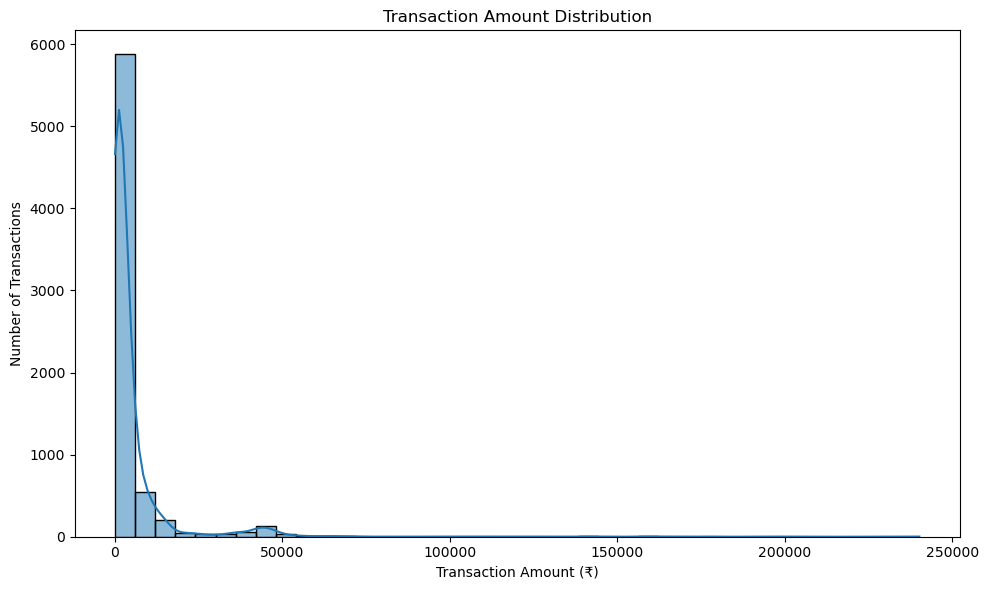

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="amount",
    bins=40,
    kde=True
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig("../reports/figures/amount_distribution.png", dpi=300)

plt.show()

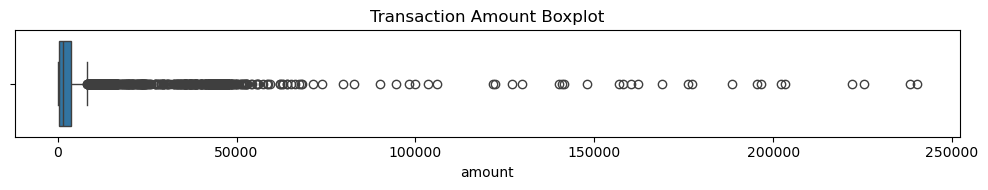

In [20]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["amount"]
)

plt.title("Transaction Amount Boxplot")

plt.tight_layout()

plt.savefig("../reports/figures/amount_boxplot.png", dpi=300)

plt.show()

In [21]:
np.log1p(df["amount"])

0        8.380879
1        7.112352
2        6.262884
3        7.163397
4       10.710007
          ...    
6995    10.741837
6996     9.512516
6997     9.519152
6998     9.454535
6999    10.440916
Name: amount, Length: 7000, dtype: float64

## Insights

Insight 1: Is the distribution skewed? 

The transaction amount distribution is positively (right) skewed, indicating that the majority of transactions are of relatively low value, while only a small proportion consist of high-value expenses. This pattern is typical of financial transaction datasets, where routine daily purchases occur frequently and large expenditures are comparatively rare.

Skewness > 0 → Right-skewed
Skewness < 0 → Left-skewed
Kurtosis > 3 → Heavy tails
Kurtosis < 3 → Light tails

Insight 2:  What is Typical Transaction Size?

The median transaction amount is a better representation of a typical transaction than the mean because the dataset is skewed. Most customer transactions fall within the lower transaction ranges, suggesting that everyday spending dominates the dataset.

Insight 3: Are there extreme Transactions?

The mean transaction amount is higher than the median, showing that a few high-value transactions significantly influence the average. These large transactions increase the overall spending average without representing the typical spending behavior of most users.

Insight 4:Does log transformation make the distribution more usable?

Applying a logarithmic transformation reduces the positive skewness of the transaction amount distribution and produces a more balanced shape. This transformation compresses the range of large values while preserving the ordering of transactions, making the feature more suitable for visualization and future machine learning models.

## Transaction Category Analysis

In [22]:
df["category"].value_counts()

category
Bills            2059
Food             1328
Groceries         912
Shopping          550
Other             435
Fuel              423
Miscellaneous     358
Subscription      242
Salary            173
Entertainment     167
Rent              165
Insurance         152
Investment         36
Name: count, dtype: int64

In [23]:
df["category"].value_counts(normalize=True) * 100

category
Bills            29.414286
Food             18.971429
Groceries        13.028571
Shopping          7.857143
Other             6.214286
Fuel              6.042857
Miscellaneous     5.114286
Subscription      3.457143
Salary            2.471429
Entertainment     2.385714
Rent              2.357143
Insurance         2.171429
Investment        0.514286
Name: proportion, dtype: float64

## Visualization

##Transaction Count by Category

In [24]:
category_count = (
    df["category"]
    .value_counts()
    .reset_index()
)

category_count.columns = ["Category", "Transaction Count"]

category_count


,Category,Transaction Count
0,Bills,2059
1,Food,1328
2,Groceries,912
3,Shopping,550
4,Other,435
5,Fuel,423
6,Miscellaneous,358
7,Subscription,242
8,Salary,173
9,Entertainment,167


#Category frequency Bar Chart

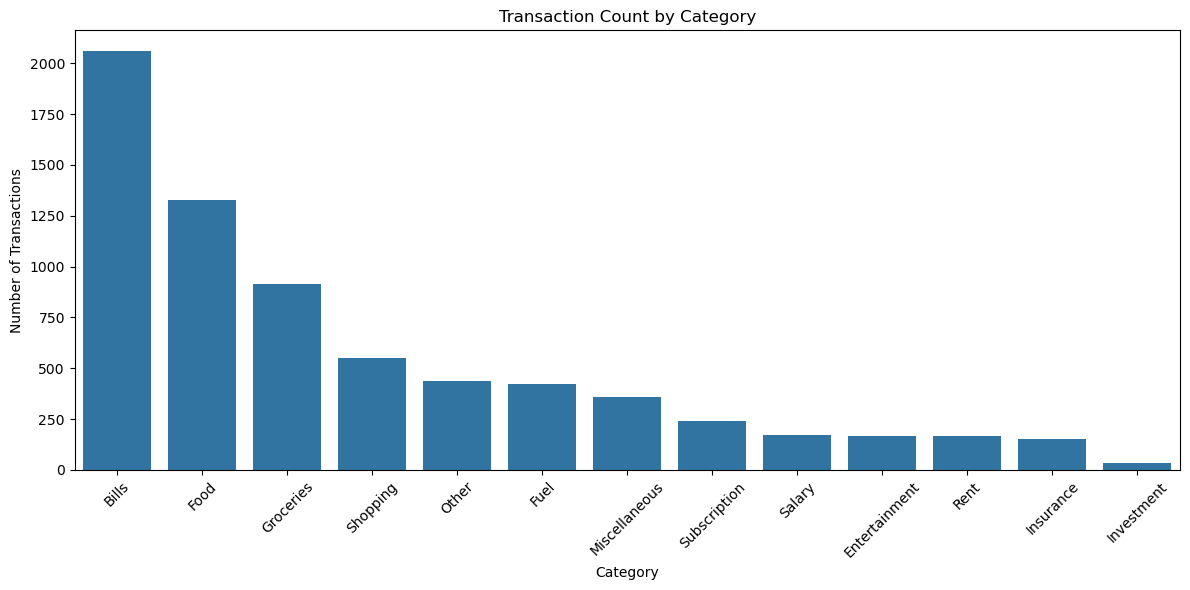

In [25]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="category",
    order=df["category"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Transaction Count by Category")

plt.xlabel("Category")

plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.savefig("../reports/figures/category_distribution.png", dpi=300)

plt.show()

##Total spending by Category

In [26]:
category_spending = (
    df.groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

category_spending.columns = [
    "Category",
    "Total Spending"
]

category_spending

,Category,Total Spending
0,Salary,11155319.21
1,Bills,9262536.46
2,Rent,4389360.17
3,Shopping,2349606.50
4,Insurance,2171275.78
5,Fuel,1255800.06
6,Groceries,1186543.15
7,Food,1069805.59
8,Investment,819101.14
9,Miscellaneous,636313.28


##Spending Bar Chart

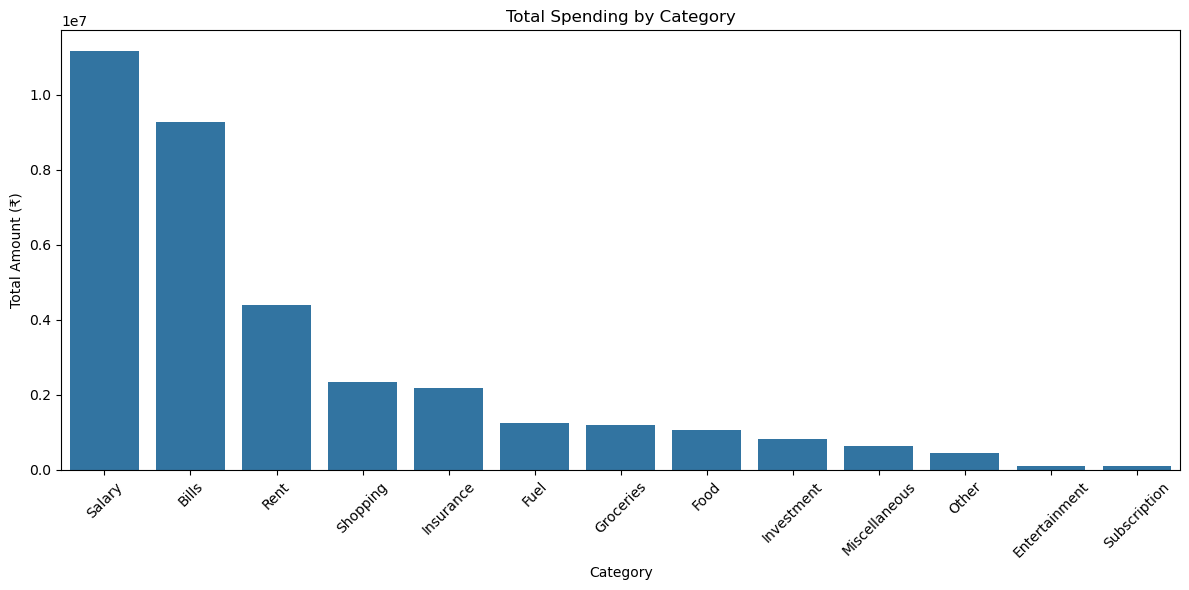

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_spending,
    x="Category",
    y="Total Spending"
)

plt.xticks(rotation=45)

plt.title("Total Spending by Category")

plt.ylabel("Total Amount (₹)")

plt.tight_layout()

plt.savefig("../reports/figures/category_spending.png", dpi=300)

plt.show()

##Average transaction amount by category

In [28]:
category_average = (
    df.groupby("category")["amount"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

category_average.columns = [
    "Category",
    "Average Transaction"
]

category_average

,Category,Average Transaction
0,Salary,64481.613931
1,Rent,26602.182848
2,Investment,22752.809444
3,Insurance,14284.709079
4,Bills,4498.560690
5,Shopping,4272.011818
6,Fuel,2968.794468
7,Miscellaneous,1777.411397
8,Groceries,1301.034156
9,Other,1013.270575


##Average Amount Plot

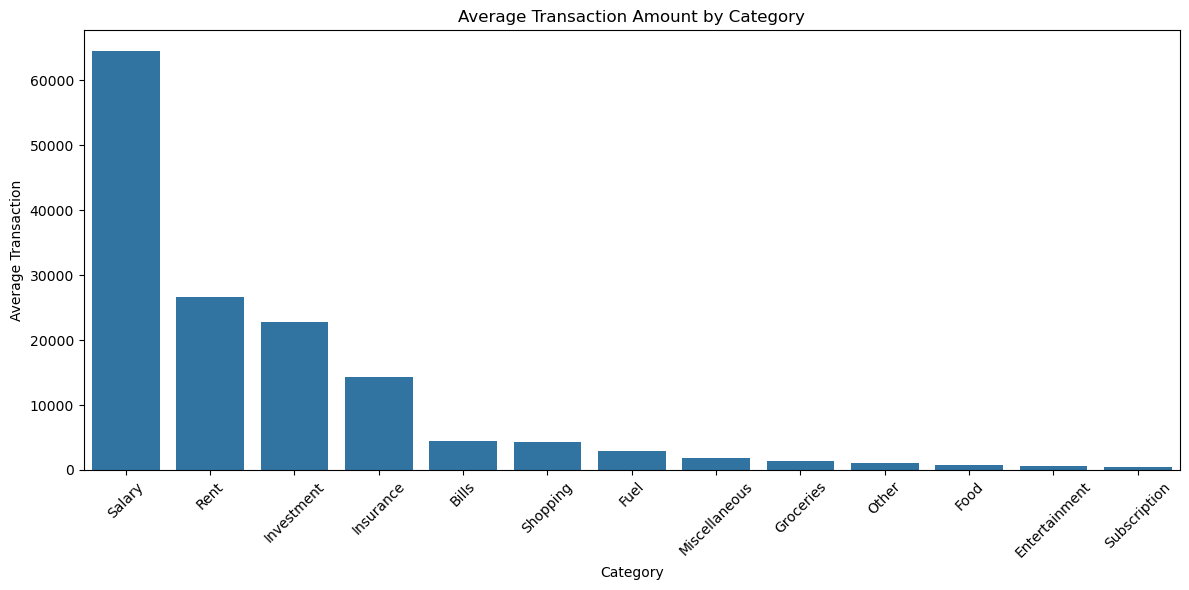

In [29]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_average,
    x="Category",
    y="Average Transaction"
)

plt.xticks(rotation=45)

plt.title("Average Transaction Amount by Category")

plt.tight_layout()

plt.savefig("../reports/figures/category_average.png", dpi=300)

plt.show()

##Median Transaction Amount

In [30]:
category_median = (
    df.groupby("category")["amount"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

category_median.columns = [
    "Category",
    "Median Transaction"
]

category_median

,Category,Median Transaction
0,Salary,46862.710
1,Rent,30940.780
2,Investment,20718.725
3,Insurance,8584.340
4,Fuel,3097.930
5,Bills,2734.380
6,Shopping,1317.845
7,Miscellaneous,875.750
8,Groceries,855.480
9,Other,783.330


##Median Transaction amount by category plot

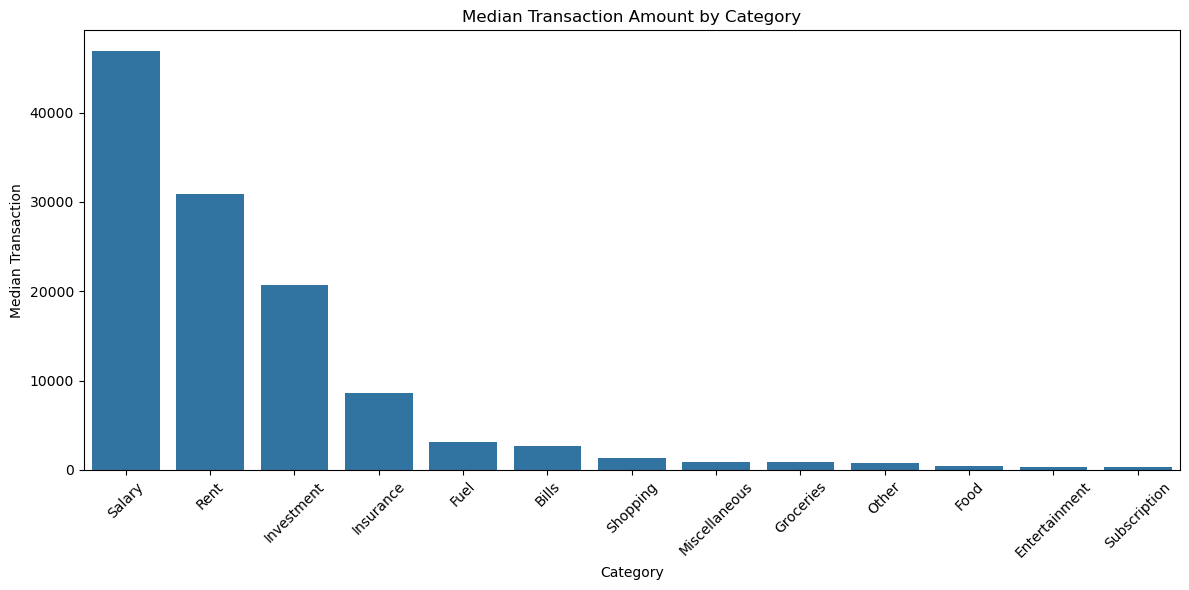

In [31]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_median,
    x="Category",
    y="Median Transaction"
)

plt.xticks(rotation=45)

plt.title("Median Transaction Amount by Category")

plt.tight_layout()

plt.savefig("../reports/figures/category_median.png", dpi=300)

plt.show()

## Insights

1. Which category has the most transactions?

The <Category Name> category records the highest number of transactions, indicating it represents the most common type of spending in the dataset.

2. Which category consumes the most money?

The <Category Name> category contributes the highest share of total spending, reflecting the largest monetary expenditure across all categories.

3. Are those the same category?

If Yes

Yes. The category with the highest transaction frequency also contributes the largest share of total spending, indicating that users spend frequently and consistently within this category.

If No

No. The category with the highest transaction frequency differs from the category with the highest total spending. This suggests that one category contains many low-value transactions, whereas another has fewer but higher-value transactions.

4. Which categories have unusually high average transactions?

Categories such as <Category A>, <Category B>, and <Category C> exhibit the highest average transaction amounts, suggesting they involve larger but less frequent expenses.

## Category Imbalance

##This is particularly important for the future Expense Classification model.

In [32]:
# Category Distribution

category_distribution = (
    df["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="transaction_count")
)

category_distribution

,category,transaction_count
0,Bills,2059
1,Food,1328
2,Groceries,912
3,Shopping,550
4,Other,435
5,Fuel,423
6,Miscellaneous,358
7,Subscription,242
8,Salary,173
9,Entertainment,167


In [33]:
# Calculate Percentage Distribution

category_distribution["percentage"] = (
    category_distribution["transaction_count"]
    / len(df)
    * 100
).round(2)

category_distribution

,category,transaction_count,percentage
0,Bills,2059,29.41
1,Food,1328,18.97
2,Groceries,912,13.03
3,Shopping,550,7.86
4,Other,435,6.21
5,Fuel,423,6.04
6,Miscellaneous,358,5.11
7,Subscription,242,3.46
8,Salary,173,2.47
9,Entertainment,167,2.39


## Visualization

##Bar Chart of percentage

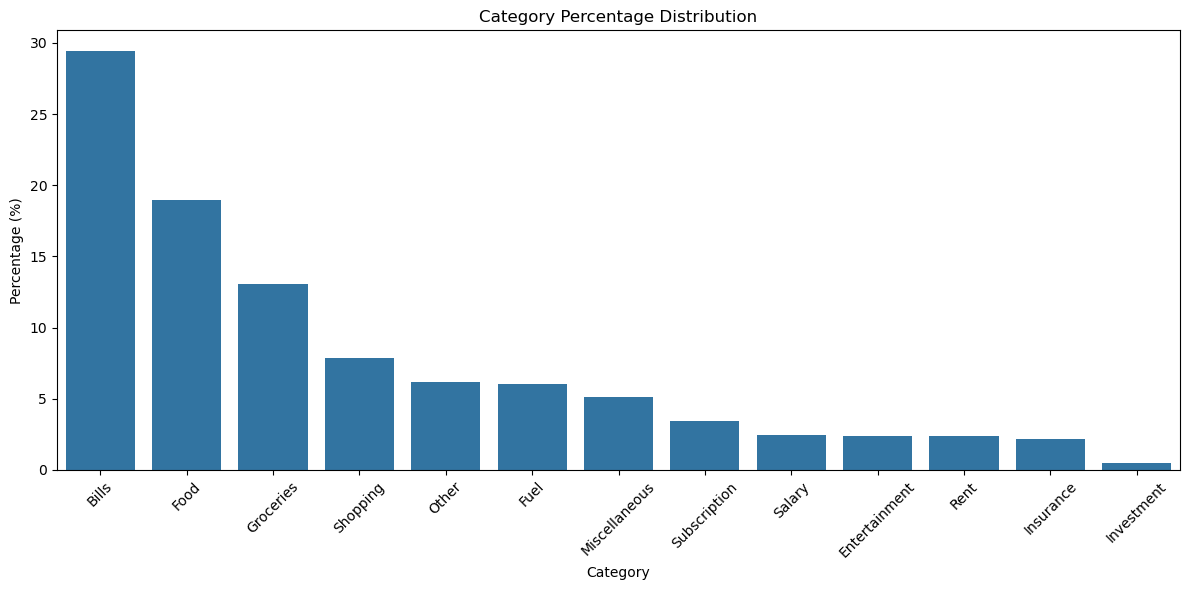

In [34]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=category_distribution,
    x="category",
    y="percentage"
)

plt.xticks(rotation=45)

plt.title("Category Percentage Distribution")

plt.xlabel("Category")
plt.ylabel("Percentage (%)")

plt.tight_layout()

plt.savefig(
    "../reports/figures/category_percentage.png",
    dpi=300
)

plt.show()

##Majority categories

In [35]:
majority_categories = category_distribution[
    category_distribution["percentage"] >= 10
]

majority_categories

,category,transaction_count,percentage
0,Bills,2059,29.41
1,Food,1328,18.97
2,Groceries,912,13.03


##Minority categories

In [36]:
minority_categories = category_distribution[
    category_distribution["percentage"] < 5
]

minority_categories

,category,transaction_count,percentage
7,Subscription,242,3.46
8,Salary,173,2.47
9,Entertainment,167,2.39
10,Rent,165,2.36
11,Insurance,152,2.17
12,Investment,36,0.51


##Rare categories


In [37]:
rare_categories = category_distribution[
    category_distribution["percentage"] < 2
]

rare_categories

,category,transaction_count,percentage
12,Investment,36,0.51


In [38]:
category_distribution.to_csv(
    "../data/processed/category_distribution.csv",
    index=False
)
print("category_distribution.csv saved successfully.")

category_distribution.csv saved successfully.


## insights

1. Which are the majority categories?

The majority categories are those contributing the largest percentage of transactions. These categories dominate the dataset and are expected to have the greatest influence on the expense classification model.

2. Which are the minority categories?

Minority categories contribute only a small proportion of transactions. Due to their limited representation, the model may struggle to learn these classes effectively.

3. Are there any rare categories?

Categories contributing less than 2% of total transactions are considered rare. These classes should be flagged because they may require special handling during model development, but no balancing techniques (such as SMOTE) should be applied during EDA, as noted in the project guidelines.

## Merchant Analysis

In [39]:
print(f"Total Unique Merchants: {df['merchant'].nunique()}")

Total Unique Merchants: 99


In [40]:
##merchant Frequency
merchant_count = (
    df["merchant"]
    .value_counts()
    .reset_index()
)

merchant_count.columns = ["Merchant", "Transaction_Count"]

merchant_count.head(20)

,Merchant,Transaction_Count
0,Credit Card Bill Payment,693
1,DMart,178
2,Airtel,175
3,Reliance Fresh,167
4,House Rent Payment,165
5,Employer Salary Credit,163
6,Indian Oil,162
7,Municipal Water Department,155
8,BigBasket,146
9,Nature's Basket,143


In [41]:
##Merchant spending 
merchant_spending = (
    df.groupby("merchant")["amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

merchant_spending.columns = [
    "Merchant",
    "Total_Spending"
]

merchant_spending.head(20)

,Merchant,Total_Spending
0,Employer Salary Credit,11146133.00
1,House Rent Payment,4389360.17
2,Credit Card Bill Payment,2333031.37
3,Bajaj Allianz,696711.29
4,Income Tax Payment,676480.16
5,Airtel,619846.61
6,ICICI Lombard,596109.30
7,Adani Electricity,594778.24
8,Jio,587892.38
9,Jio Fiber,582560.01


## Visualization

##Top 20 merchants by transaction count

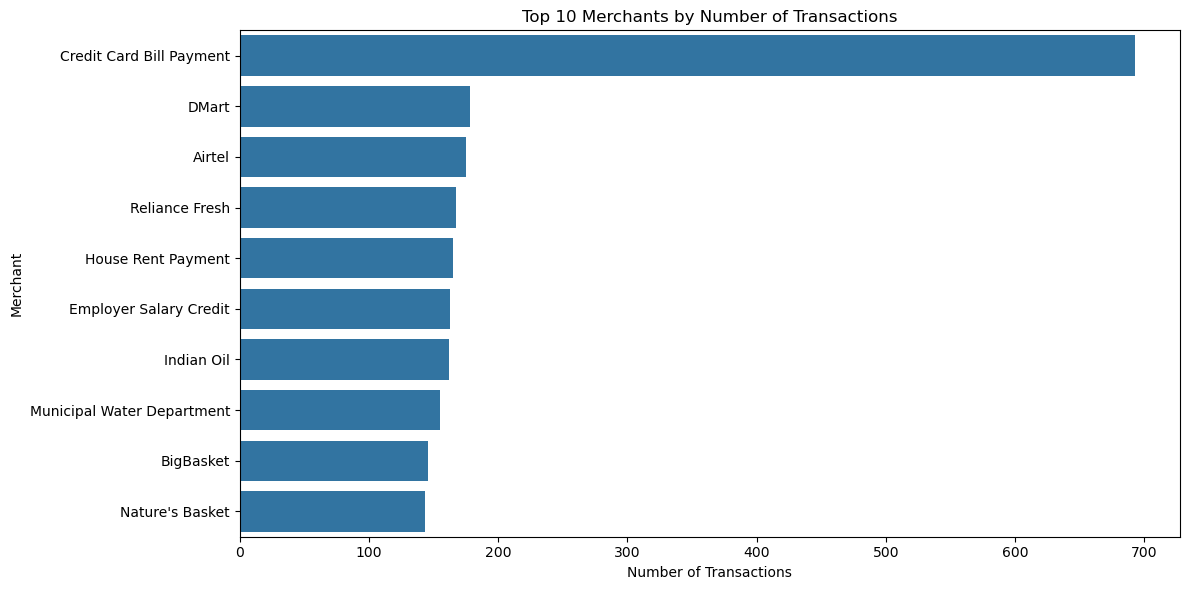

In [42]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=merchant_count.head(10),
    x="Transaction_Count",
    y="Merchant"
)

plt.title("Top 10 Merchants by Number of Transactions")

plt.xlabel("Number of Transactions")
plt.ylabel("Merchant")

plt.tight_layout()

plt.savefig("../reports/figures/top_merchants_transactions.png", dpi=300)

plt.show()

##Top 20 merchants by total spending

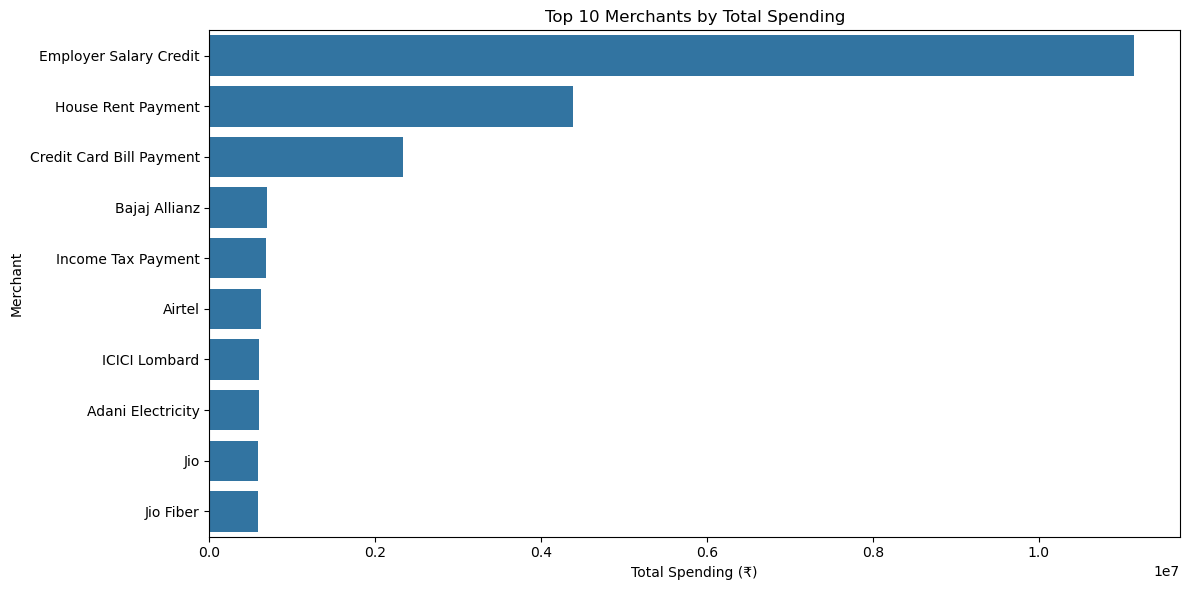

In [43]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=merchant_spending.head(10),
    x="Total_Spending",
    y="Merchant"
)

plt.title("Top 10 Merchants by Total Spending")

plt.xlabel("Total Spending (₹)")
plt.ylabel("Merchant")

plt.tight_layout()

plt.savefig("../reports/figures/top_merchants_spending.png", dpi=300)

plt.show()

##merchant Average transaction

In [44]:
merchant_average = (
    df.groupby("merchant")["amount"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

merchant_average.columns = [
    "Merchant",
    "Average_Transaction"
]

merchant_average.head(20)

,Merchant,Average_Transaction
0,Employer Salary Credit,68381.184049
1,ICICI Prudential MF,29341.973333
2,House Rent Payment,26602.182848
3,HDFC Mutual Fund,21536.512500
4,Mutual Fund SIP,20119.638182
5,Income Tax Payment,18791.115556
6,Bajaj Allianz,15834.347500
7,ICICI Lombard,15284.853846
8,EMI Home Loan,15186.630667
9,SBI Mutual Fund,14677.868000


## Insights


1. Which merchants occur most frequently?

The most frequent merchants represent customers' regular spending habits and preferred vendors. These merchants are typically associated with everyday expenses such as groceries, food, fuel, and shopping.

2. Which merchants account for the most spending?

The highest-spending merchants receive the largest share of customer expenditure. These merchants may have either frequent transactions or high-value purchases.

3. Which merchants have high average transaction values?

Merchants with high average transaction values are associated with expensive purchases rather than frequent transactions. They often represent categories such as electronics, travel, healthcare, or luxury retail.

## Merchant-Category Relationship


##merchant count in each category

In [45]:
merchant_category_count = (
    df.groupby(["category", "merchant"])
      .size()
      .reset_index(name="Transaction_Count")
)

merchant_category_count.head(10)

,category,merchant,Transaction_Count
0,Bills,Adani Electricity,98
1,Bills,Airtel,175
2,Bills,BEST,108
3,Bills,BSNL,111
4,Bills,Bharat Gas,100
5,Bills,Credit Card Bill Payment,693
6,Bills,EMI Home Loan,30
7,Bills,EMI Personal Loan,29
8,Bills,HP Gas,84
9,Bills,Income Tax Payment,36


In [46]:
pd.crosstab(
df["merchant"],
df["category"]
)

category,Bills,Entertainment,Food,Fuel,Groceries,Insurance,Investment,Miscellaneous,Other,Rent,Salary,Shopping,Subscription
merchant,,,,,,,,,,,,,
ATM,0,0,0,0,0,0,0,0,17,0,0,0,0
Ace Hardware India,0,0,0,0,0,0,0,59,0,0,0,0,0
Adani Electricity,98,0,0,0,0,0,0,0,0,0,0,0,0
Airtel,175,0,0,0,0,0,0,0,0,0,0,0,0
Airtel Digital TV,0,0,0,0,0,0,0,0,0,0,0,0,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Uber,0,0,0,0,0,0,0,21,0,0,0,0,0
Unknown Merchant,0,0,0,0,0,0,0,0,28,0,0,0,0
Vegetable Market,0,0,0,0,0,0,0,0,27,0,0,0,0


##merchants appearing under multiple categories

In [47]:
merchant_category_counts = (
df.groupby("merchant")["category"]
.nunique()
)
merchant_category_counts[
merchant_category_counts > 1
]

merchant
Amazon Prime       2
Disney+ Hotstar    2
Netflix            2
Name: category, dtype: int64

## Visualization

##heatmap for the most frequent merchants

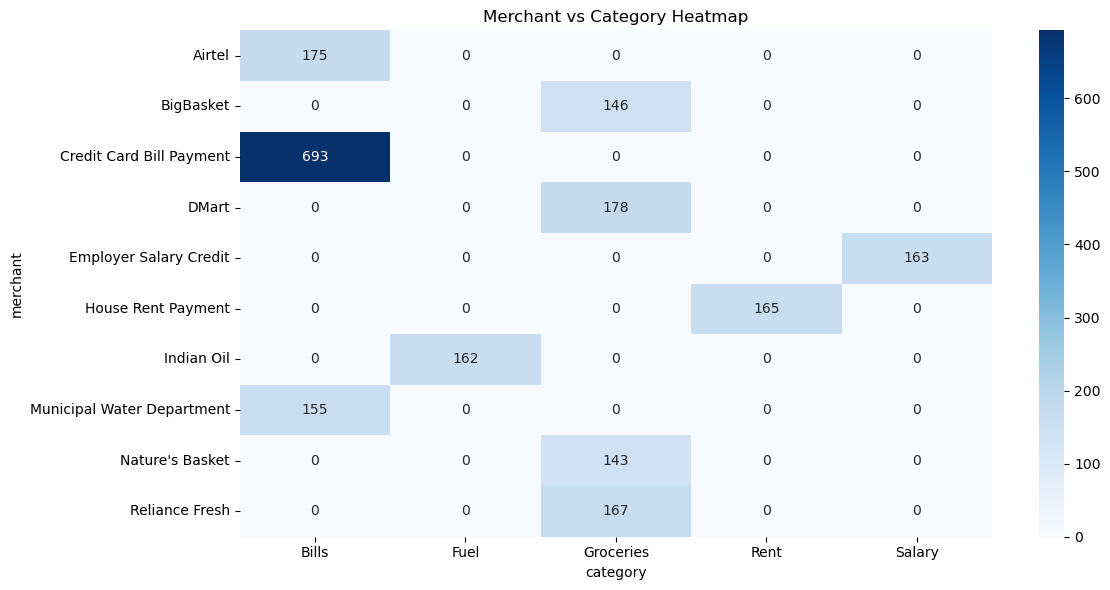

In [48]:
top10_merchants = (
    df["merchant"]
    .value_counts()
    .head(10)
    .index
)

heatmap_data = pd.crosstab(
    df[df["merchant"].isin(top10_merchants)]["merchant"],
    df[df["merchant"].isin(top10_merchants)]["category"]
)

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Merchant vs Category Heatmap")

plt.tight_layout()

plt.savefig(
    "../reports/figures/merchant_category_heatmap.png",
    dpi=300
)

plt.show()

In [49]:
merchant_category_summary = (
    df.groupby(["category", "merchant"])
      .agg(
          Transaction_Count=("amount","count"),
          Total_Spending=("amount","sum"),
          Average_Transaction=("amount","mean")
      )
      .round(2)
      .reset_index()
)

merchant_category_summary.to_csv(
    "../reports/merchant_category_summary.csv",
    index=False
)

merchant_category_summary.head()

,category,merchant,Transaction_Count,Total_Spending,Average_Transaction
0,Bills,Adani Electricity,98,594778.24,6069.17
1,Bills,Airtel,175,619846.61,3541.98
2,Bills,BEST,108,529828.59,4905.82
3,Bills,BSNL,111,457372.17,4120.47
4,Bills,Bharat Gas,100,267541.77,2675.42


## Insights

1. Does each merchant consistently belong to one category?

Most merchants are consistently associated with a single transaction category, indicating reliable merchant categorization. A few merchants may appear in multiple categories due to offering diverse products or services.

2. Which merchants appear across multiple categories?

Merchants appearing in multiple categories are typically large retailers or online platforms that provide a wide range of products and services. These merchants contribute to diverse customer spending patterns across categories.

3. Are those multiple categories legitimate or data errors?

Most multi-category assignments are legitimate for merchants with diversified business operations. However, unexpected category assignments should be reviewed during data validation to identify possible labeling inconsistencies or data quality issues.

## Description Analysis

##Basic statistic

In [50]:
print("Total Descriptions :", len(df["description"]))
print("Unique Descriptions :", df["description"].nunique())
print("Duplicate Descriptions :", df["description"].duplicated().sum())

Total Descriptions : 7000
Unique Descriptions : 1176
Duplicate Descriptions : 5824


##most common description

In [51]:
description_count = (
    df["description"]
    .value_counts()
    .reset_index()
)

description_count.columns = [
    "Description",
    "Transaction_Count"
]

description_count.head(20)

,Description,Transaction_Count
0,Auto Debit Credit Card Bill Payment,369
1,Net Banking Payment Credit Card Bill Payment,273
2,NEFT Salary Credit,163
3,Auto Debit Airtel,85
4,Auto Debit Municipal Water Department,79
5,POS Purchase Amazon India,70
6,Auto Debit Jio,67
7,Auto Debit Spotify,60
8,Auto Debit Jio Fiber,58
9,Auto Debit BSNL,57


##Description summary

In [52]:
description_summary = (
    df.groupby("description")
      .agg(
          Transaction_Count=("amount","count"),
          Total_Spending=("amount","sum"),
          Average_Amount=("amount","mean")
      )
      .round(2)
      .sort_values("Transaction_Count", ascending=False)
)

description_summary.head(20)

,Transaction_Count,Total_Spending,Average_Amount
description,,,
Auto Debit Credit Card Bill Payment,369,1245882.74,3376.38
Net Banking Payment Credit Card Bill Payment,273,876480.47,3210.55
NEFT Salary Credit,163,11146133.00,68381.18
Auto Debit Airtel,85,287718.59,3384.92
Auto Debit Municipal Water Department,79,181767.45,2300.85
POS Purchase Amazon India,70,335381.46,4791.16
Auto Debit Jio,67,264520.46,3948.07
Auto Debit Spotify,60,11157.59,185.96
Auto Debit Jio Fiber,58,265489.62,4577.41


## Insights

• Are descriptions unique enough?

Most transaction descriptions are unique enough to distinguish individual transactions, while repeated descriptions indicate recurring payments or similar transaction types.

• Do descriptions contain merchant information?

Yes, many transaction descriptions include merchant names or transaction references, making them useful for merchant identification and expense categorization.

• Are descriptions repetitive?

Some descriptions are repetitive due to recurring transactions such as subscriptions, utility bills, EMIs, and salary payments, while most remain transaction-specific.

• Do descriptions provide enough information for NLP?

Yes, transaction descriptions contain meaningful textual information that can be leveraged for NLP tasks such as merchant extraction, transaction classification, and spending pattern analysis.

## Conclusion

The description column is highly valuable for a future NLP-based Expense Classification model. It contains meaningful textual information such as merchant names, transaction references, and payment details, which can be used to accurately classify transactions, extract merchants, identify recurring payments, and generate personalized financial insights.

## Visualization


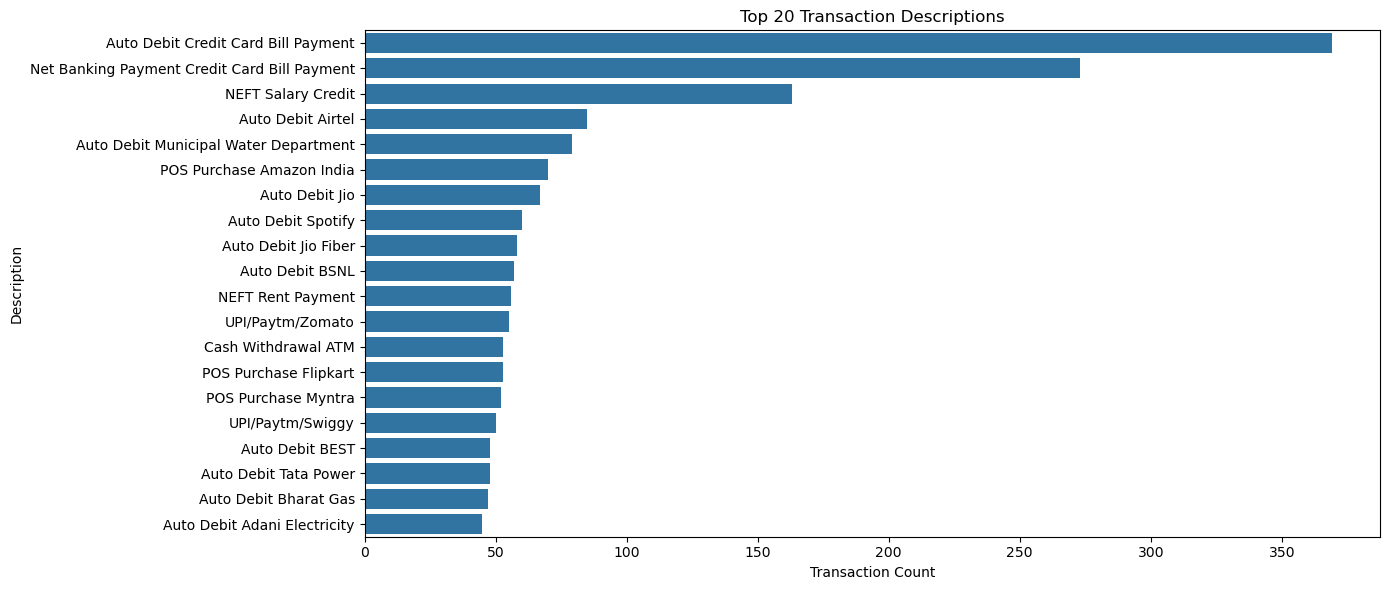

In [53]:
##Top 10 descriptions plot
plt.figure(figsize=(14,6))

sns.barplot(
    data=description_count.head(20),
    x="Transaction_Count",
    y="Description"
)

plt.title("Top 20 Transaction Descriptions")

plt.xlabel("Transaction Count")
plt.ylabel("Description")

plt.tight_layout()

plt.savefig("../reports/figures/top_transaction_descriptions.png", dpi=300)

plt.show()

## Payment Method Analysis

##Payment Method Distribution (Frequency)

In [54]:
payment_count = (
    df["payment_method"]
    .value_counts()
    .reset_index()
)

payment_count.columns = [
    "Payment_Method",
    "Transaction_Count"
]

payment_count

,Payment_Method,Transaction_Count
0,UPI,2607
1,Auto Debit,1333
2,Debit Card,1053
3,Net Banking,816
4,Credit Card,697
5,NEFT,307
6,Cash Withdrawal,95
7,IMPS,92


##payment method percentage

In [55]:
payment_percentage = (
    df["payment_method"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

payment_percentage.columns = [
    "Payment_Method",
    "Percentage"
]

payment_percentage

,Payment_Method,Percentage
0,UPI,37.24
1,Auto Debit,19.04
2,Debit Card,15.04
3,Net Banking,11.66
4,Credit Card,9.96
5,NEFT,4.39
6,Cash Withdrawal,1.36
7,IMPS,1.31


##Total Spending by Payment Method

In [56]:
payment_spending = (
    df.groupby("payment_method")["amount"]
    .sum()
    .reset_index(name="Total_Spending")
    .sort_values("Total_Spending", ascending=False)
)

payment_spending

,payment_method,Total_Spending
5,NEFT,10687865.54
0,Auto Debit,5882966.23
7,UPI,5087142.15
4,IMPS,5058929.74
6,Net Banking,4984690.93
3,Debit Card,1777301.11
2,Credit Card,1258713.49
1,Cash Withdrawal,190122.08


##Average Transaction 

In [57]:
payment_average = (
    df.groupby("payment_method")["amount"]
    .mean()
    .reset_index(name="Average_Transaction")
    .sort_values("Average_Transaction", ascending=False)
)

payment_average

,payment_method,Average_Transaction
4,IMPS,54988.366739
5,NEFT,34813.894267
6,Net Banking,6108.689865
0,Auto Debit,4413.328005
1,Cash Withdrawal,2001.285053
7,UPI,1951.339528
2,Credit Card,1805.901707
3,Debit Card,1687.845309


## Visualization

##payment method Frequency


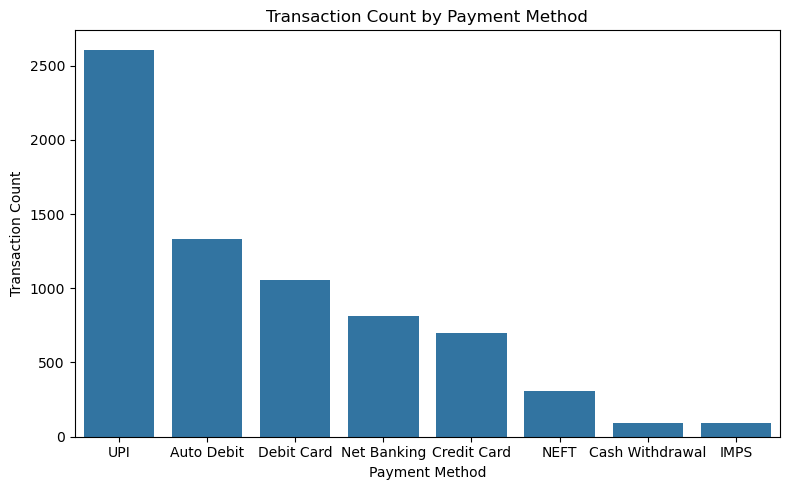

In [58]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="payment_method",
    order=df["payment_method"].value_counts().index
)

plt.title("Transaction Count by Payment Method")

plt.xlabel("Payment Method")
plt.ylabel("Transaction Count")

plt.tight_layout()

plt.savefig("../reports/figures/payment_method_distribution.png", dpi=300)

plt.show()

##payment method spending

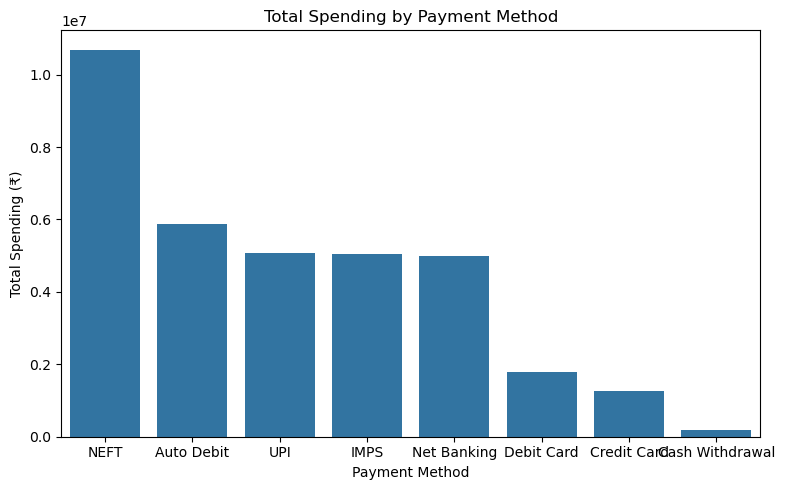

In [59]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=payment_spending,
    x="payment_method",
    y="Total_Spending"
)

plt.title("Total Spending by Payment Method")

plt.xlabel("Payment Method")
plt.ylabel("Total Spending (₹)")

plt.tight_layout()

plt.savefig("../reports/figures/payment_method_spending.png", dpi=300)

plt.show()

## Insights

• Which payment method is dominant?

The dominant payment method is the one with the highest transaction count, indicating it is the most preferred mode of payment among customers. Its widespread usage reflects convenience and customer trust.

• Does UPI dominate?

If UPI records the highest transaction count and spending, it dominates the payment ecosystem, highlighting the strong adoption of digital payments. Otherwise, another payment method is more prevalent in the dataset.

• Which payment method has the highest average transaction?

The payment method with the highest average transaction value is generally used for larger purchases rather than frequent everyday transactions. This suggests customers prefer it for high-value payments.

## Payment Method * Category

##Payment Method vs Category Frequency

In [60]:
payment_category = pd.crosstab(
    df["category"],
    df["payment_method"]
)

payment_category

payment_method,Auto Debit,Cash Withdrawal,Credit Card,Debit Card,IMPS,NEFT,Net Banking,UPI
category,,,,,,,,
Bills,1042,0,0,0,0,91,682,244
Entertainment,0,0,44,42,0,0,0,81
Food,0,0,208,331,0,0,0,789
Fuel,0,31,19,146,0,0,7,220
Groceries,0,0,131,252,0,0,0,529
Insurance,84,0,0,0,0,0,68,0
Investment,19,0,0,0,0,0,0,17
Miscellaneous,0,18,76,119,0,0,0,145
Other,0,46,0,26,0,0,0,363


## Visualization

##Heatmap


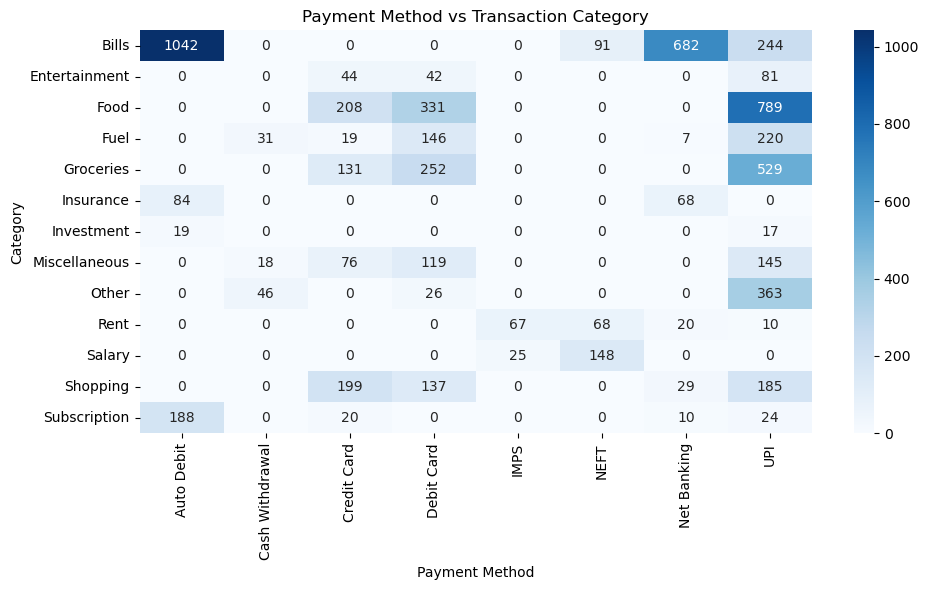

In [61]:
plt.figure(figsize=(10,6))

sns.heatmap(
    payment_category,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Payment Method vs Transaction Category")

plt.xlabel("Payment Method")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig("../reports/figures/payment_category_heatmap.png", dpi=300)

plt.show()

##Percentage-based version

In [62]:
pd.crosstab(
df["category"],
df["payment_method"],
normalize="index"
) * 100

payment_method,Auto Debit,Cash Withdrawal,Credit Card,Debit Card,IMPS,NEFT,Net Banking,UPI
category,,,,,,,,
Bills,50.607091,0.000000,0.000000,0.000000,0.000000,4.419621,33.122875,11.850413
Entertainment,0.000000,0.000000,26.347305,25.149701,0.000000,0.000000,0.000000,48.502994
Food,0.000000,0.000000,15.662651,24.924699,0.000000,0.000000,0.000000,59.412651
Fuel,0.000000,7.328605,4.491726,34.515366,0.000000,0.000000,1.654846,52.009456
Groceries,0.000000,0.000000,14.364035,27.631579,0.000000,0.000000,0.000000,58.004386
Insurance,55.263158,0.000000,0.000000,0.000000,0.000000,0.000000,44.736842,0.000000
Investment,52.777778,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,47.222222
Miscellaneous,0.000000,5.027933,21.229050,33.240223,0.000000,0.000000,0.000000,40.502793
Other,0.000000,10.574713,0.000000,5.977011,0.000000,0.000000,0.000000,83.448276


## Insights

• Are food purchases mostly UPI?

If UPI has the highest number of food transactions, it indicates that customers prefer fast and convenient digital payments for everyday food purchases. Otherwise, another payment method is more commonly used for this category.

• Are shopping purchases mostly cards?

If card payments dominate shopping transactions, it suggests customers prefer cards for medium- to high-value retail purchases. Otherwise, the leading payment method reflects the dominant customer payment preference for shopping.

• Are bills mostly auto-debit?

If auto-debit is the primary payment method for bill transactions, it indicates customers prefer automated recurring payments for convenience and timely bill settlement. Otherwise, customers predominantly use manual payment methods for bill payments.

## Debit VS Credit Analysis

##Transaction type distribution

In [63]:
transaction_type_count = (
    df["transaction_type"]
    .value_counts()
    .reset_index()
)

transaction_type_count.columns = [
    "Transaction_Type",
    "Transaction_Count"
]

transaction_type_count

,Transaction_Type,Transaction_Count
0,Debit,6810
1,Credit,190


##Total amount

In [64]:
transaction_amount = (
    df.groupby("transaction_type")["amount"]
      .sum()
      .reset_index(name="Total_Amount")
)

transaction_amount

,transaction_type,Total_Amount
0,Credit,11230573.44
1,Debit,23697157.83


##Summary

In [65]:
debit_credit_summary = (
    df.groupby("transaction_type")
      .agg(
          Transaction_Count=("amount", "count"),
          Total_Amount=("amount", "sum"),
          Average_Amount=("amount", "mean"),
          Median_Amount=("amount", "median"),
          Minimum=("amount", "min")
      )
      .round(2)
)

debit_credit_summary

,Transaction_Count,Total_Amount,Average_Amount,Median_Amount,Minimum
transaction_type,,,,,
Credit,190,11230573.44,59108.28,45968.56,114.38
Debit,6810,23697157.83,3479.76,1327.34,30.74


## Visualization

##Debit Vs Credit count

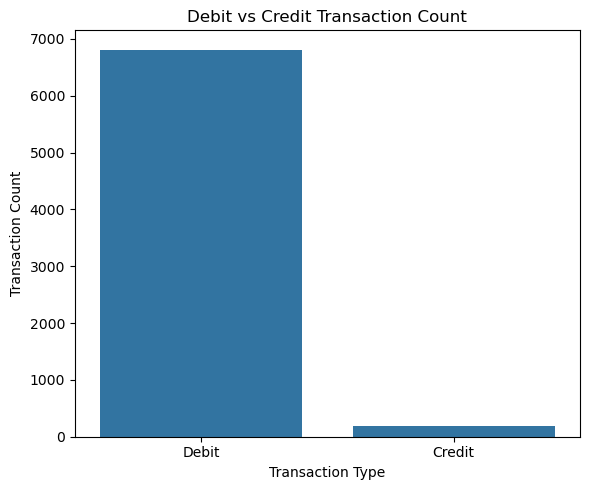

In [66]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="transaction_type",
    order=df["transaction_type"].value_counts().index
)

plt.title("Debit vs Credit Transaction Count")

plt.xlabel("Transaction Type")
plt.ylabel("Transaction Count")

plt.tight_layout()

plt.savefig("../reports/figures/debit_credit_count.png", dpi=300)

plt.show()

##Debit VS Credit amount

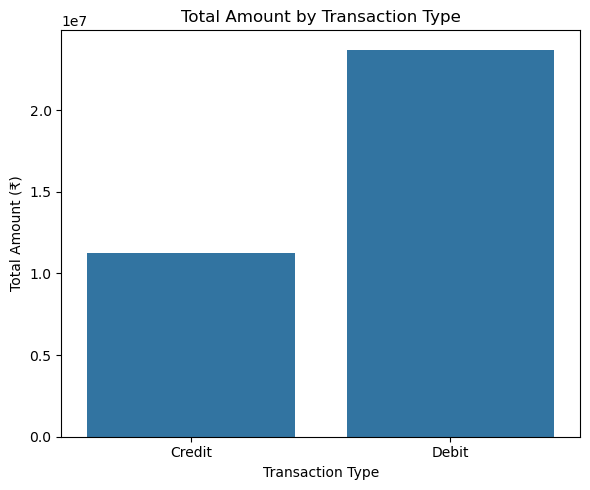

In [67]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=transaction_amount,
    x="transaction_type",
    y="Total_Amount"
)

plt.title("Total Amount by Transaction Type")

plt.xlabel("Transaction Type")
plt.ylabel("Total Amount (₹)")

plt.tight_layout()

plt.savefig("../reports/figures/debit_credit_amount.png", dpi=300)

plt.show()

## Insights

• What percentage of transactions are income vs expenses?

The percentage of credit (income) and debit (expense) transactions reflects the overall balance between money inflows and outflows. A higher proportion of debit transactions indicates that most financial activity is related to spending.

• What is the total money coming in?

The total value of credit transactions represents the overall income or money inflow during the observed period. This includes sources such as salaries, refunds, and other credits.

• What is the total money going out?

The total value of debit transactions represents the overall expenditure or money outflow. This includes everyday purchases, bill payments, transfers, and other expenses.

## Debit/Credit * Category

##Debit/Credit * Category frequency

In [68]:
transaction_category = pd.crosstab(
    df["category"],
    df["transaction_type"]
)

transaction_category

transaction_type,Credit,Debit
category,,
Bills,0,2059
Entertainment,0,167
Food,0,1328
Fuel,0,423
Groceries,0,912
Insurance,0,152
Investment,0,36
Miscellaneous,0,358
Other,0,435


##dominant transaction type (Debit/Credit)

In [69]:
# Transaction count by Category and Transaction Type
category_transaction = (
    df.groupby(["category", "transaction_type"])
      .size()
      .reset_index(name="Transaction_Count")
)

# Identify dominant transaction type for each category
dominant_transaction_type = (
    category_transaction
    .sort_values(
        ["category", "Transaction_Count"],
        ascending=[True, False]
    )
    .drop_duplicates(subset="category")
    .reset_index(drop=True)
)

dominant_transaction_type

,category,transaction_type,Transaction_Count
0,Bills,Debit,2059
1,Entertainment,Debit,167
2,Food,Debit,1328
3,Fuel,Debit,423
4,Groceries,Debit,912
5,Insurance,Debit,152
6,Investment,Debit,36
7,Miscellaneous,Debit,358
8,Other,Debit,435
9,Rent,Debit,165


In [70]:
# Categories dominated by Debit
debit_categories = dominant_transaction_type[
    dominant_transaction_type["transaction_type"] == "Debit"
]

print("Categories Mostly Debit")
display(debit_categories)

Categories Mostly Debit


,category,transaction_type,Transaction_Count
0,Bills,Debit,2059
1,Entertainment,Debit,167
2,Food,Debit,1328
3,Fuel,Debit,423
4,Groceries,Debit,912
5,Insurance,Debit,152
6,Investment,Debit,36
7,Miscellaneous,Debit,358
8,Other,Debit,435
9,Rent,Debit,165


In [71]:
# Categories dominated by Credit
credit_categories = dominant_transaction_type[
    dominant_transaction_type["transaction_type"] == "Credit"
]

print("Categories Mostly Credit")
display(credit_categories)

Categories Mostly Credit


,category,transaction_type,Transaction_Count
10,Salary,Credit,173


In [72]:
#Total Amount by Category & Transaction Type
category_transaction_amount = (
    df.groupby(["category", "transaction_type"])["amount"]
      .sum()
      .reset_index()
)

category_transaction_amount.head(10)

,category,transaction_type,amount
0,Bills,Debit,9262536.46
1,Entertainment,Debit,98075.37
2,Food,Debit,1069805.59
3,Fuel,Debit,1255800.06
4,Groceries,Debit,1186543.15
5,Insurance,Debit,2171275.78
6,Investment,Debit,819101.14
7,Miscellaneous,Debit,636313.28
8,Other,Debit,440772.70
9,Rent,Debit,4389360.17


## Visualization

##transaction category pivot

In [73]:
category_transaction_pivot = category_transaction_amount.pivot(
    index="category",
    columns="transaction_type",
    values="amount"
).fillna(0)

category_transaction_pivot

transaction_type,Credit,Debit
category,,
Bills,0.00,9262536.46
Entertainment,0.00,98075.37
Food,0.00,1069805.59
Fuel,0.00,1255800.06
Groceries,0.00,1186543.15
Insurance,0.00,2171275.78
Investment,0.00,819101.14
Miscellaneous,0.00,636313.28
Other,0.00,440772.70


##Amount Heatmap

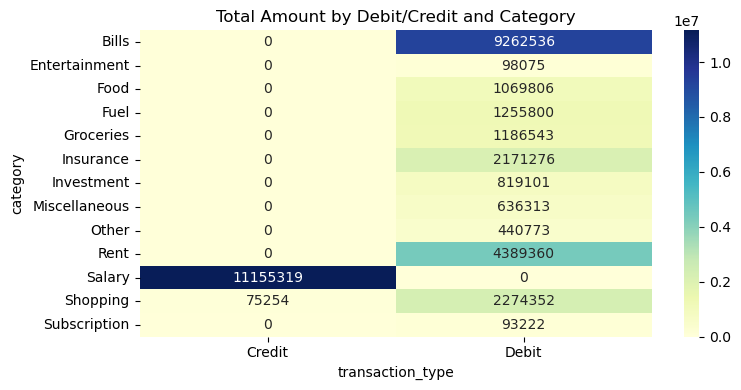

In [74]:
plt.figure(figsize=(8,4))

sns.heatmap(
    category_transaction_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Total Amount by Debit/Credit and Category")

plt.tight_layout()

plt.savefig("../reports/figures/debit_credit_category_amount_heatmap.png", dpi=300)

plt.show()

## Insights

• Which categories are mostly debit?

Categories dominated by debit transactions represent routine expenses such as shopping, groceries, food, bills, and entertainment. These categories primarily contribute to customers' cash outflows.

• Which categories are mostly credit?

Categories dominated by credit transactions represent income sources such as salary, refunds, cashback, or other account credits. These categories contribute to overall cash inflows.

• Are there unexpected debit/credit combinations?

If expense categories contain many credit transactions or income categories contain many debit transactions, they may indicate refunds, reversals, transfers, or potential data quality issues that should be reviewed.

• What does this imply?

The debit/credit distribution across categories provides valuable insights into customer cash flow and supports feature engineering for income-expense analysis, budgeting, and financial wellness prediction.

## Geographic Analysis

##State analysis

In [75]:
df["state"].value_counts()

state
Maharashtra       1331
Karnataka         1015
Uttar Pradesh      866
Gujarat            788
Madhya Pradesh     452
Delhi              432
Kerala             432
Tamil Nadu         431
Rajasthan          431
Telangana          431
West Bengal        391
Name: count, dtype: int64

##transaction by state


In [76]:
state_transactions = (
    df.groupby("state")
      .agg(
          Transaction_Count=("amount", "count"),
          Total_Spending=("amount", "sum"),
          Average_Transaction=("amount", "mean")
      )
      .round(2)
      .sort_values("Transaction_Count", ascending=False)
)

state_transactions

,Transaction_Count,Total_Spending,Average_Transaction
state,,,
Maharashtra,1331,6620210.61,4973.86
Karnataka,1015,4058300.11,3998.33
Uttar Pradesh,866,5150738.23,5947.73
Gujarat,788,3502413.62,4444.69
Madhya Pradesh,452,2231175.33,4936.23
Delhi,432,2669952.99,6180.45
Kerala,432,1632701.14,3779.40
Rajasthan,431,2725658.41,6324.03
Tamil Nadu,431,2475298.55,5743.15


##transaction by amount


In [77]:
df.groupby("amount").sum()

,transaction_id,transaction_date,transaction_time,merchant,description,currency,payment_method,transaction_type,category,city,state,country,day,week,month,weekend,month_end,salary_week,festival_season
amount,,,,,,,,,,,,,,,,,,,
30.74,TXN004565,2019-06-30,18:26:57,General Store,UPI/General Store,INR,UPI,Debit,Other,Chennai,Tamil Nadu,India,30,26,6,1,1,1,0
32.02,TXN004873,2019-09-05,17:31:55,Street Vendor,UPI/Street Vendor,INR,UPI,Debit,Other,Kochi,Kerala,India,5,36,9,0,0,0,0
33.31,TXN002946,2018-07-07,13:01:15,Tea Stall,UPI/Tea Stall,INR,UPI,Debit,Other,Delhi,Delhi,India,7,27,7,1,0,0,0
33.51,TXN003463,2018-11-03,15:06:52,Tea Stall,UPI/Tea Stall,INR,UPI,Debit,Other,Jaipur,Rajasthan,India,3,44,11,1,0,0,1
34.47,TXN002001,2018-01-01,00:09:16,Tea Stall,UPI/Tea Stall,INR,UPI,Debit,Other,Nagpur,Maharashtra,India,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203265.19,TXN005372,2019-06-04,21:14:15,Employer Salary Credit,NEFT Salary Credit,INR,IMPS,Credit,Salary,Chennai,Tamil Nadu,India,4,23,6,0,0,0,0
222120.88,TXN005465,2019-04-03,13:55:52,Employer Salary Credit,NEFT Salary Credit,INR,NEFT,Credit,Salary,Jaipur,Rajasthan,India,3,14,4,0,0,0,0
225266.29,TXN006660,2019-02-05,11:04:09,Employer Salary Credit,NEFT Salary Credit,INR,NEFT,Credit,Salary,Chennai,Tamil Nadu,India,5,6,2,0,0,0,0


##Transaction by city

In [91]:
city_transactions = (
    df.groupby("city")
      .agg(
          Transaction_Count=("amount", "count"),
          Total_Spending=("amount", "sum"),
          Average_Transaction=("amount", "mean")
      )
      .round(2)
      .sort_values("Transaction_Count", ascending=False)
)

city_transactions.head(10)

,Transaction_Count,Total_Spending,Average_Transaction
city,,,
Bengaluru,1015,4058300.11,3998.33
Indore,452,2231175.33,4936.23
Nagpur,450,2393275.11,5318.39
Pune,447,2191234.81,4902.09
Noida,444,2559236.26,5764.05
Mumbai,434,2035700.69,4690.55
Delhi,432,2669952.99,6180.45
Kochi,432,1632701.14,3779.40
Chennai,431,2475298.55,5743.15


##City Analysis

In [78]:
# Top 15 cities by transaction count
top15_city_transactions = (
    df.groupby("city")
      .agg(Transaction_Count=("amount", "count"))
      .sort_values("Transaction_Count", ascending=False)
      .head(15)
)

top15_city_transactions


,Transaction_Count
city,
Bengaluru,1015
Indore,452
Nagpur,450
Pune,447
Noida,444
Mumbai,434
Delhi,432
Kochi,432
Chennai,431


In [79]:
# Top 15 cities by total spending
top15_city_spending = (
    df.groupby("city")
      .agg(Total_Spending=("amount", "sum"))
      .sort_values("Total_Spending", ascending=False)
      .head(15)
      .round(2)
)

top15_city_spending

,Total_Spending
city,
Bengaluru,4058300.11
Jaipur,2725658.41
Delhi,2669952.99
Lucknow,2591501.97
Noida,2559236.26
Chennai,2475298.55
Nagpur,2393275.11
Indore,2231175.33
Pune,2191234.81


In [80]:
# Top 15 cities by average transaction amount
top15_city_average = (
    df.groupby("city")
      .agg(Average_Spending=("amount", "mean"))
      .sort_values("Average_Spending", ascending=False)
      .head(15)
      .round(2)
)

top15_city_average

,Average_Spending
city,
Jaipur,6324.03
Delhi,6180.45
Lucknow,6141.00
Noida,5764.05
Chennai,5743.15
Nagpur,5318.39
Indore,4936.23
Kolkata,4903.09
Pune,4902.09


## Visualization

##Top states plot


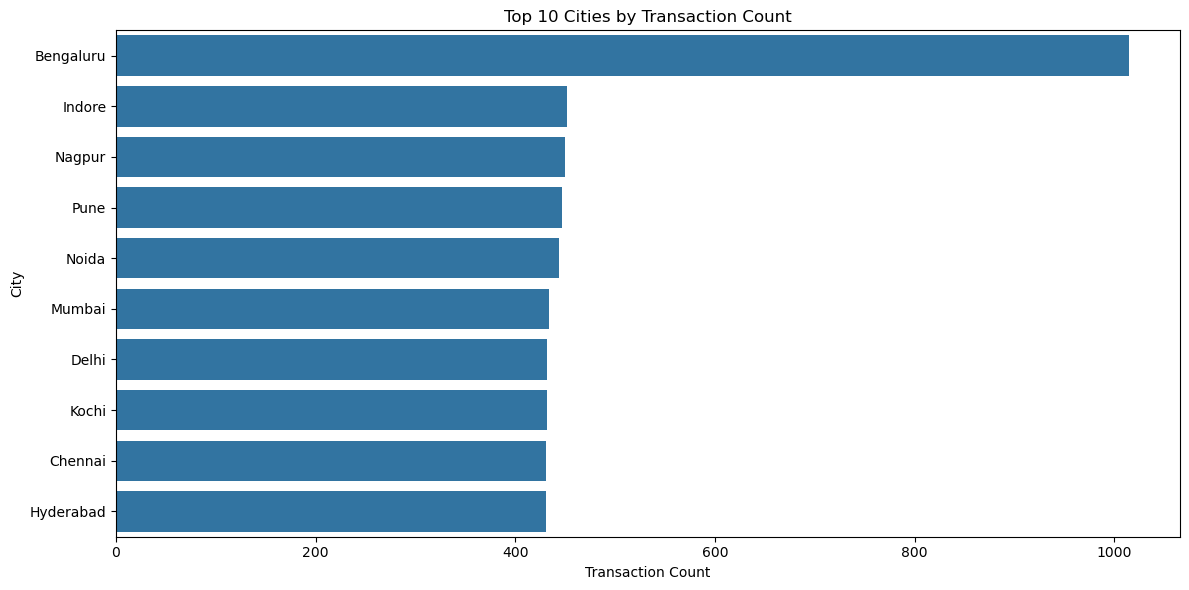

In [92]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=city_transactions.head(10).reset_index(),
    x="Transaction_Count",
    y="city"
)

plt.title("Top 10 Cities by Transaction Count")
plt.xlabel("Transaction Count")
plt.ylabel("City")

plt.tight_layout()
plt.savefig("../reports/figures/top_cities_transactions.png", dpi=300)
plt.show()

## Insights

• Which state has the most transactions?**

The state with the highest transaction count represents the region with the most active customer base and the highest frequency of financial transactions.

• Which state has the highest spending?**

The state with the highest total spending contributes the largest share of transaction value, indicating stronger purchasing activity or higher-value transactions.

• Does transaction volume correlate with spending?**

Generally, states with higher transaction volumes also tend to have higher total spending, suggesting a positive correlation between customer activity and expenditure. However, exceptions may occur if some states have fewer but higher-value transactions.


## Country and Currency validation


In [82]:
df["country"].value_counts()


country
India    7000
Name: count, dtype: int64

In [83]:
df["currency"].value_counts()

currency
INR    7000
Name: count, dtype: int64

In [84]:
# convert date column 
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

In [85]:
df["Year"] = df["transaction_date"].dt.year

In [93]:
df["Month"] = df["transaction_date"].dt.month

In [87]:
df["WeekDay_Name"] = df["transaction_date"].dt.day_name()

In [88]:
#transaction count by Year
yearly_transactions = (
    df.groupby("Year")
      .size()
      .reset_index(name="Transaction_Count")
)

yearly_transactions

,Year,Transaction_Count
0,2018,4126
1,2019,2874


In [94]:
#transaction count by Month
monthly_transactions = (
    df.groupby("Month")
      .size()
      .reset_index(name="Transaction_Count")
)

In [ ]:
monthly_transactions

,Month,Transaction_Count
0,1,561
1,2,596
2,3,697
3,4,745
4,5,651
5,6,681
6,7,667
7,8,626
8,9,704
9,10,320


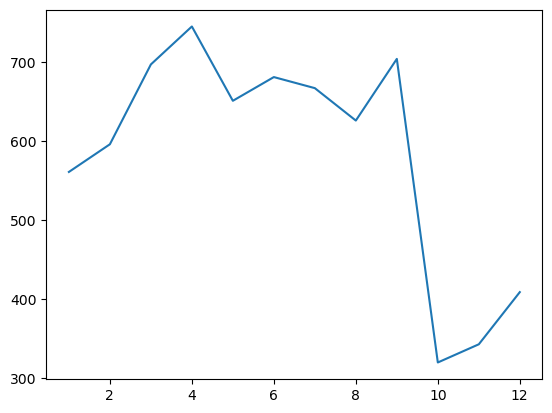

In [ ]:
plt.plot(monthly_transactions["Month"], monthly_transactions["Transaction_Count"])

In [ ]:
#monthly spending
monthly_spending = (
    df.groupby("Month")["amount"]
      .sum()
      .reset_index(name="Total_Spending")
)


In [ ]:
monthly_spending

,Year,Month,Month_Name,Total_Spending
0,2018,1,1,1438113.98
1,2018,2,2,1642197.38
2,2018,3,3,1930640.78
3,2018,4,4,1834703.67
4,2018,5,5,1884881.62
5,2018,6,6,1757331.39
6,2018,7,7,1705792.30
7,2018,8,8,1499952.40
8,2018,9,9,1526738.93
9,2018,10,10,1279155.81


In [ ]:
print(monthly_transactions.columns)

Index(['Month', 'Transaction_Count'], dtype='object')


## Visualization


##Monyhly transaction plot

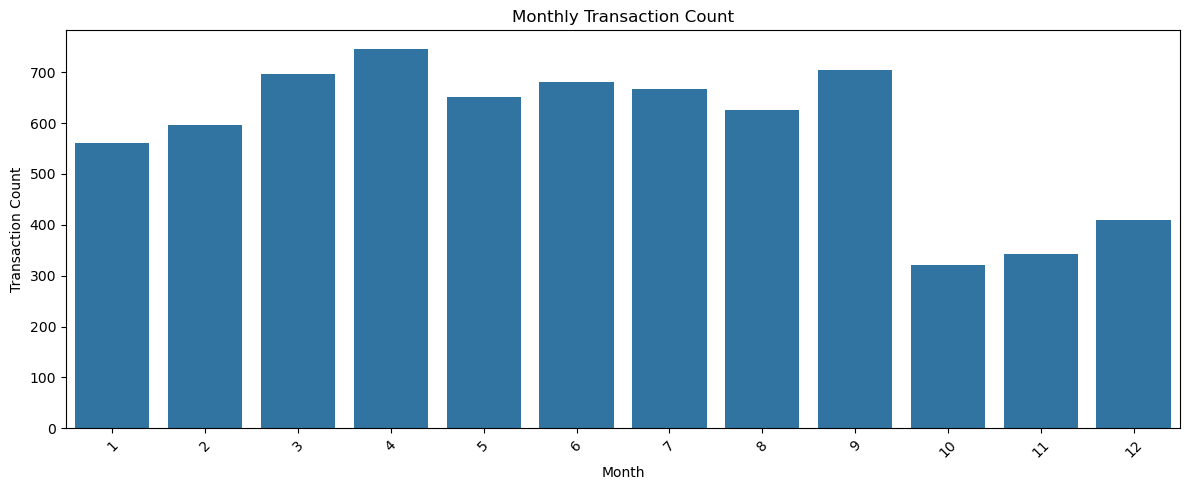

In [ ]:


plt.figure(figsize=(12,5))

sns.barplot(
    data=monthly_transactions,
    x="Month",
    y="Transaction_Count" , 
    
)


plt.title("Monthly Transaction Count")
plt.xlabel("Month")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##monthly spending plot

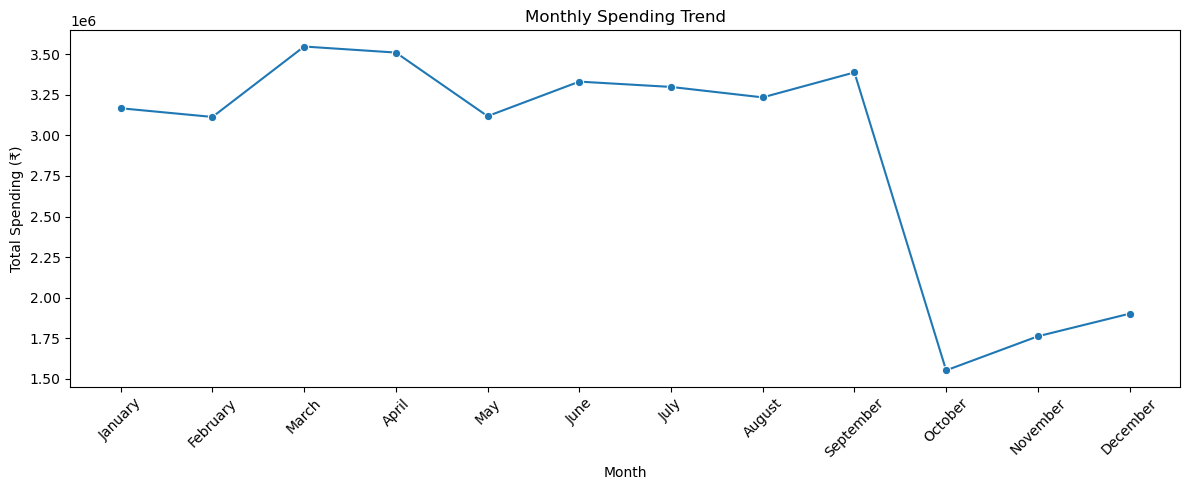

In [ ]:
monthly_spending = monthly_spending.sort_values("Month")

plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_spending,
    x="Month",
    y="Total_Spending",
    marker="o"
)

plt.xticks(
    ticks=range(1, 13),
    labels=month_order,
    rotation=45
)

plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spending (₹)")

plt.tight_layout()
plt.show()

## Insights

• Which month has the highest number of transactions?

The month with the highest transaction count represents the period of maximum customer activity. This may reflect seasonal spending trends or festive shopping periods.

• Which month has the highest spending?

The month with the highest total spending indicates the period when customers make the largest purchases. This often coincides with holidays, festivals, or promotional events.

• Are there weekday vs weekend spending patterns?

Differences in transaction volume or spending between weekdays and weekends reveal variations in customer purchasing behavior. Such patterns can help identify peak shopping days.

• Is there seasonality in transactions?

Recurring peaks or declines across specific months or quarters indicate seasonal spending behavior. Identifying seasonality is valuable for forecasting and financial trend analysis.

## Transaction Volume over time 

##Daily transaction volume

In [ ]:
daily_transactions = (
    df.groupby("transaction_date")
      .size()
      .reset_index(name="Transaction_Count")
)

daily_transactions.head()

,transaction_date,Transaction_Count
0,2018-01-01,11
1,2018-01-02,13
2,2018-01-03,8
3,2018-01-04,10
4,2018-01-05,15


## Visualization

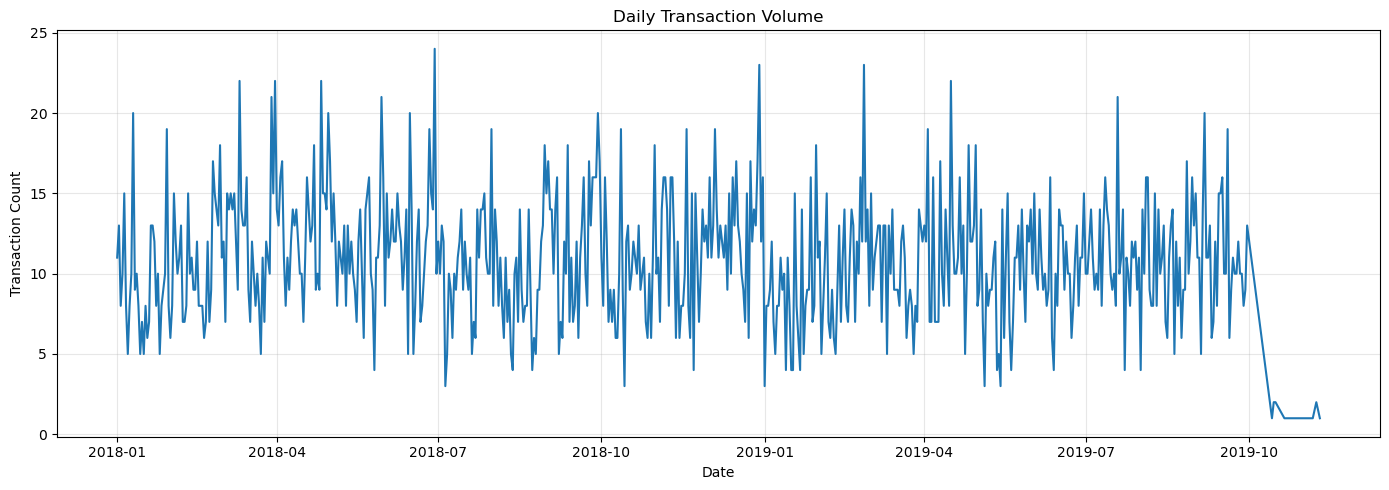

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(
    daily_transactions["transaction_date"],
    daily_transactions["Transaction_Count"],
    linewidth=1.5
)

plt.title("Daily Transaction Volume")
plt.xlabel("Date")
plt.ylabel("Transaction Count")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../reports/figures/daily_transaction_volume.png", dpi=300)

plt.show()

## Insights

• Are transactions evenly distributed?

Transactions are evenly distributed if daily or weekly transaction counts remain relatively stable over time. Significant fluctuations indicate varying customer activity rather than a uniform distribution.

• Are there periods with unusually high activity?

Sharp spikes in transaction volume may correspond to salary days, festivals, promotional campaigns, or seasonal events. These peaks represent periods of unusually high customer activity.

• Are there gaps in the data?

Periods with no or very few transactions may indicate missing records, system downtime, or low business activity. Such gaps should be investigated to ensure data completeness before modeling.

## Daily Spending Over Time

In [ ]:
#Daily Spending 
daily_spending = (
    df.groupby("transaction_date")["amount"]
      .sum()
      .reset_index(name="Total_Spending")
)

daily_spending.head()

,transaction_date,Total_Spending
0,2018-01-01,77103.28
1,2018-01-02,99601.47
2,2018-01-03,28836.12
3,2018-01-04,52272.13
4,2018-01-05,117374.98


## Visualization

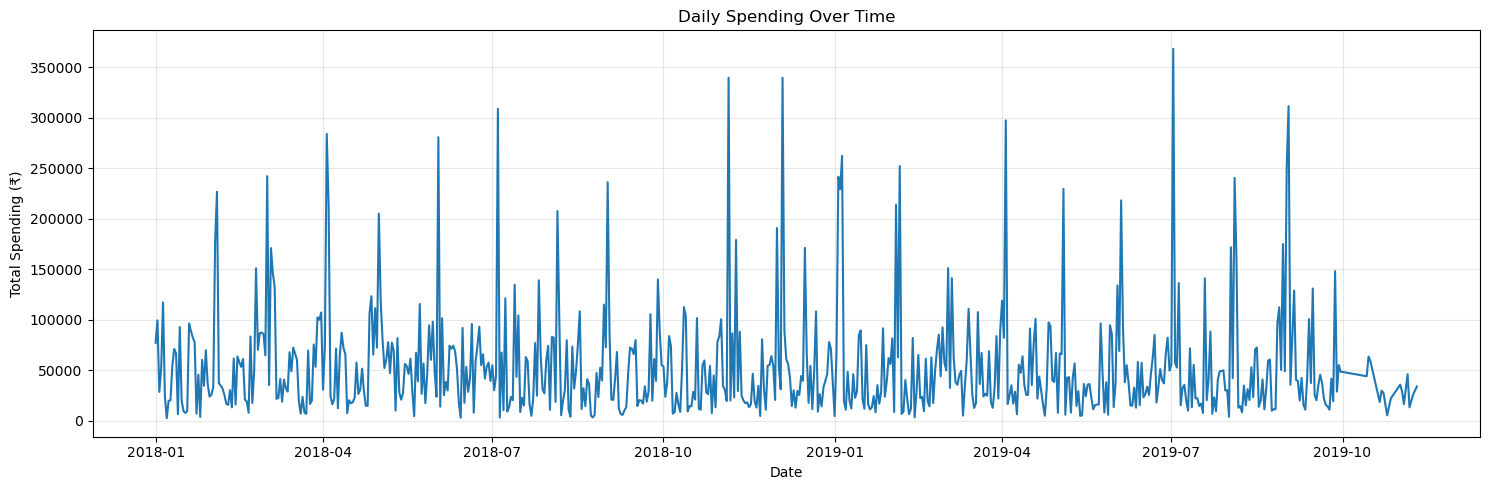

In [ ]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_spending["transaction_date"],
    daily_spending["Total_Spending"],
    linewidth=1.5
)

plt.title("Daily Spending Over Time")
plt.xlabel("Date")
plt.ylabel("Total Spending (₹)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../reports/figures/daily_spending_over_time.png", dpi=300)

plt.show()

In [ ]:
# highest spending days
top_spending_days = (
    daily_spending
    .sort_values("Total_Spending", ascending=False)
    .head(10)
)

top_spending_days

,transaction_date,Total_Spending
547,2019-07-02,368455.30
308,2018-11-05,339903.13
337,2018-12-04,339758.43
609,2019-09-02,311712.15
184,2018-07-04,308985.30
457,2019-04-03,297573.71
92,2018-04-03,284168.46
152,2018-06-02,280895.75
369,2019-01-05,262439.57
400,2019-02-05,252298.75


## Insights

• Spending trends?

Daily spending generally follows the overall transaction activity, with fluctuations reflecting changing customer spending behavior over time. A stable or upward trend indicates consistent or growing financial activity.

• High-spending days?

The highest-spending days represent periods of increased customer expenditure, often associated with salary credits, festivals, holidays, or major shopping events.

• Sudden spikes?

Sudden spikes in daily spending indicate unusual financial activity that may result from seasonal events, promotions, bulk purchases, or exceptional transactions and should be investigated further.

## Monthly Spending

In [ ]:
#Mothly Total Spending 
monthly_spending = (
    df.groupby(["Year", "Month", "Month_Name"])["amount"]
      .sum()
      .reset_index(name="Total_Spending")
      .sort_values(["Year", "Month"])
)

monthly_spending.head()

,Year,Month,Month_Name,Total_Spending
0,2018,1,1,1438113.98
1,2018,2,2,1642197.38
2,2018,3,3,1930640.78
3,2018,4,4,1834703.67
4,2018,5,5,1884881.62


## Visualization


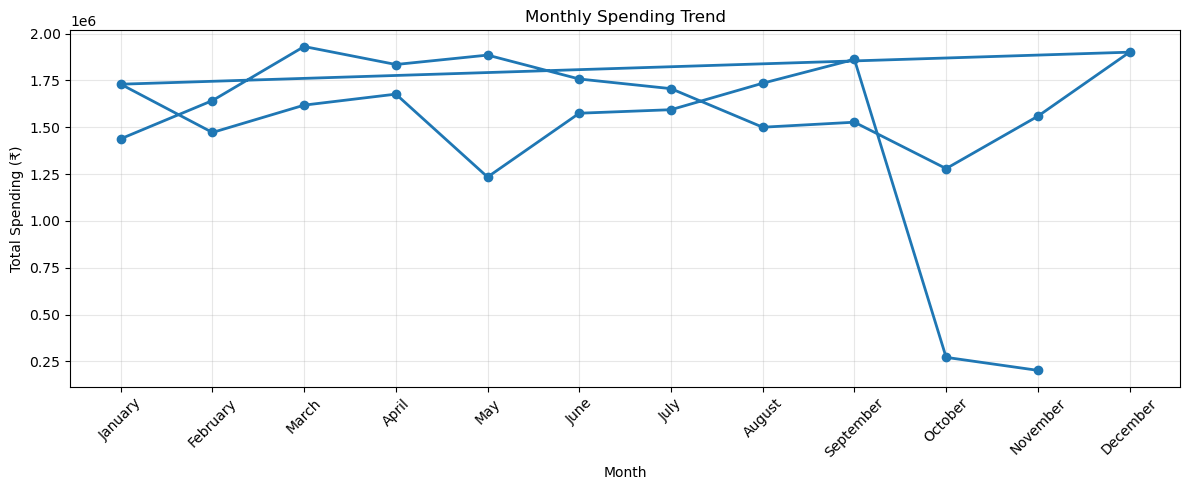

In [ ]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

plt.figure(figsize=(12,5))

plt.plot(
    monthly_spending["Month"],
    monthly_spending["Total_Spending"],
    marker="o",
    linewidth=2
)

plt.xticks(
    ticks=range(1,13),
    labels=month_order,
    rotation=45
)

plt.title("Monthly Spending Trend")
plt.xlabel("Month")
plt.ylabel("Total Spending (₹)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../reports/figures/monthly_spending_trend.png", dpi=300)

plt.show()

In [ ]:
#Highest Spending Months
top_months = (
    monthly_spending
    .sort_values("Total_Spending", ascending=False)
    .head(10)
)

top_months

,Year,Month,Month_Name,Total_Spending
2,2018,3,3,1930640.78
11,2018,12,12,1900490.53
4,2018,5,5,1884881.62
20,2019,9,9,1862013.13
3,2018,4,4,1834703.67
5,2018,6,6,1757331.39
19,2019,8,8,1734785.03
12,2019,1,1,1729567.52
6,2018,7,7,1705792.30
15,2019,4,4,1676585.73


## Insights

• Which month has the highest spending?

The month with the highest total spending represents the period of maximum customer expenditure, often driven by seasonal events, festivals, or major shopping periods.

• Which month has the lowest spending?

The month with the lowest total spending indicates reduced customer purchasing activity and may represent off-season or lower financial activity.

• Is there seasonality in spending?

Recurring increases or decreases in monthly spending suggest seasonal customer behavior, which can be useful for forecasting and budgeting.

• Is there a trend?

The monthly spending trend shows whether customer expenditure remains stable or follows a consistent upward or downward pattern over time. Recurring peaks and declines may indicate seasonal spending behavior.

## Monthly Category Spending

In [ ]:
df["Month_Name"] = df["transaction_date"].dt.month_name()

In [ ]:
monthly_category_spending = (
    df.groupby(["Year", "Month", "Month_Name", "category"])["amount"]
      .sum()
      .reset_index(name="Total_Spending")
      .sort_values(["Year", "Month"])
)

monthly_category_spending.head()

,Year,Month,Month_Name,category,Total_Spending
0,2018,1,January,Bills,437458.23
1,2018,1,January,Entertainment,3589.87
2,2018,1,January,Food,46873.99
3,2018,1,January,Fuel,53104.32
4,2018,1,January,Groceries,50949.27


In [ ]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time', 'merchant',
       'description', 'amount', 'currency', 'payment_method',
       'transaction_type', 'category', 'city', 'state', 'country', 'day',
       'week', 'month', 'weekend', 'month_end', 'salary_week',
       'festival_season', 'Year', 'Month', 'WeekDay_Name', 'Month_name',
       'Month_Name'],
      dtype='object')

In [ ]:
# Convert date column
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

# Create consistent month columns
df["Year"] = df["transaction_date"].dt.year
df["Month"] = df["transaction_date"].dt.month
df["Month_Name"] = df["transaction_date"].dt.month_name()
df["WeekDay_Name"] = df["transaction_date"].dt.day_name()

# Monthly category spending
monthly_category_spending = (
    df.groupby(["Year", "Month", "Month_Name", "category"], dropna=False)["amount"]
      .sum()
      .reset_index(name="Total_Spending")
      .sort_values(["Year", "Month"])
)

# Pivot table with month names
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

category_month_pivot = (
    monthly_category_spending.pivot_table(
        index="Month_Name",
        columns="category",
        values="Total_Spending",
        aggfunc="sum",
        fill_value=0
    )
    .reindex(month_order, fill_value=0)
)

category_month_pivot

category,Bills,Entertainment,Food,Fuel,Groceries,Insurance,Investment,Miscellaneous,Other,Rent,Salary,Shopping,Subscription
Month_Name,,,,,,,,,,,,,
January,906577.74,6611.87,77696.67,106101.91,103887.59,190167.76,119706.37,62662.86,32850.45,308560.70,1141720.26,105774.11,5363.21
February,904412.69,7944.87,78334.11,90411.65,93471.58,167947.51,6045.93,57272.21,28253.78,340359.82,1168126.17,165377.80,6147.78
March,996630.98,14138.98,113233.05,113436.45,109904.98,307433.73,40468.32,45266.34,45349.94,392661.95,1157341.83,203093.90,9540.87
April,1025515.27,9460.92,101774.60,128244.78,150872.50,130509.48,201469.22,47651.94,52685.76,361561.93,1176756.03,116465.64,8321.33
May,816049.82,10533.92,91836.43,116044.45,103713.81,211625.40,38032.80,78776.20,42668.93,500600.03,831688.14,269227.15,8154.95
June,1015776.51,11176.88,89723.79,145251.30,74312.83,248650.89,42028.38,88337.49,39348.00,390035.96,1072014.64,100280.71,15078.06
July,757109.65,9165.31,93597.78,106698.75,102699.51,201542.47,73905.21,47276.26,45442.27,505738.69,1171940.44,174531.63,9617.11
August,783422.67,7975.29,108530.58,122101.67,108831.60,238699.84,113815.55,51635.80,50234.87,403230.80,1124814.74,111698.39,9745.63
September,822376.03,8310.45,130019.28,136620.82,150805.16,202732.93,88488.08,50228.88,37701.82,414540.35,1184748.95,153621.82,8557.49


## Visualization

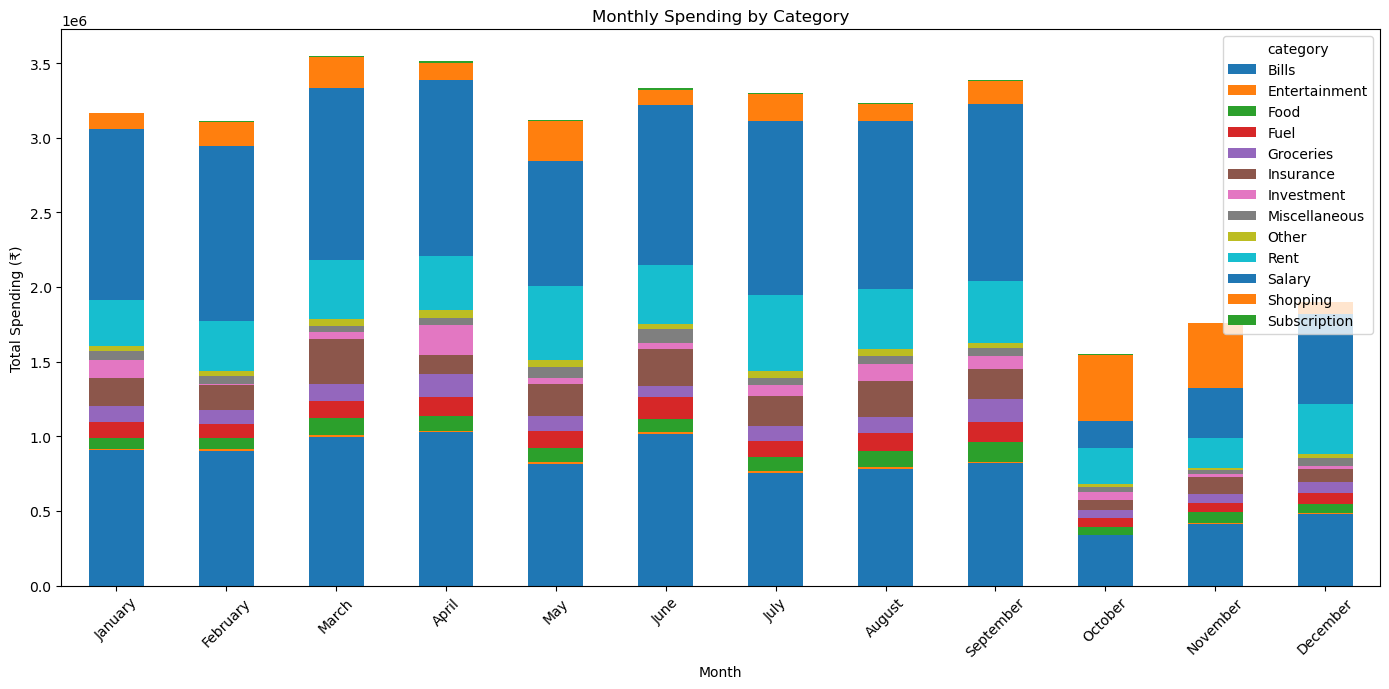

In [ ]:
#Stacked Bar Chart for Monthly Spending by Category
category_month_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7)
)

plt.title("Monthly Spending by Category")
plt.xlabel("Month")
plt.ylabel("Total Spending (₹)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/figures/monthly_category_stacked.png",
    dpi=300
)

plt.show()

In [95]:
###This is one of the most important anlyses for your Budget Recommendation system

## Insights

• Which category dominates each month?

The category with the highest spending each month represents customers' primary expense during that period. Consistent dominance indicates stable spending priorities.

• Are some categories seasonal?

Categories showing spending spikes only in specific months suggest seasonal behavior, such as festival shopping, travel, or holiday-related expenses.

• Which category has the highest yearly spending?

The category with the largest cumulative spending across all months represents the biggest contributor to annual customer expenses.

• Do spending patterns change over the year?

Variations in monthly category spending indicate changing customer priorities and seasonal purchasing behavior throughout the year.

## Weekday Analysis


In [100]:
weekday_transactions = (
    df.groupby("weekday_name")
      .size()
      .reindex([
          "Monday",
          "Tuesday",
          "Wednesday",
          "Thursday",
          "Friday",
          "Saturday",
          "Sunday"
      ])
      .reset_index(name="Transaction_Count")
)

weekday_transactions

,weekday_name,Transaction_Count
0,Monday,994
1,Tuesday,1019
2,Wednesday,1044
3,Thursday,955
4,Friday,1043
5,Saturday,983
6,Sunday,962


In [101]:
weekday_summary = (
    df.groupby("weekday_name")
      .agg(
          Transaction_Count=("amount", "count"),
          Total_Spending=("amount", "sum"),
          Average_Transaction=("amount", "mean")
      )
      .reindex([
          "Monday",
          "Tuesday",
          "Wednesday",
          "Thursday",
          "Friday",
          "Saturday",
          "Sunday"
      ])
      .round(2)
)

weekday_summary

,Transaction_Count,Total_Spending,Average_Transaction
weekday_name,,,
Monday,994,4537552.39,4564.94
Tuesday,1019,5185215.94,5088.53
Wednesday,1044,4627952.69,4432.90
Thursday,955,4256269.16,4456.83
Friday,1043,6583983.24,6312.54
Saturday,983,4754646.56,4836.87
Sunday,962,4982111.29,5178.91


## Visualization

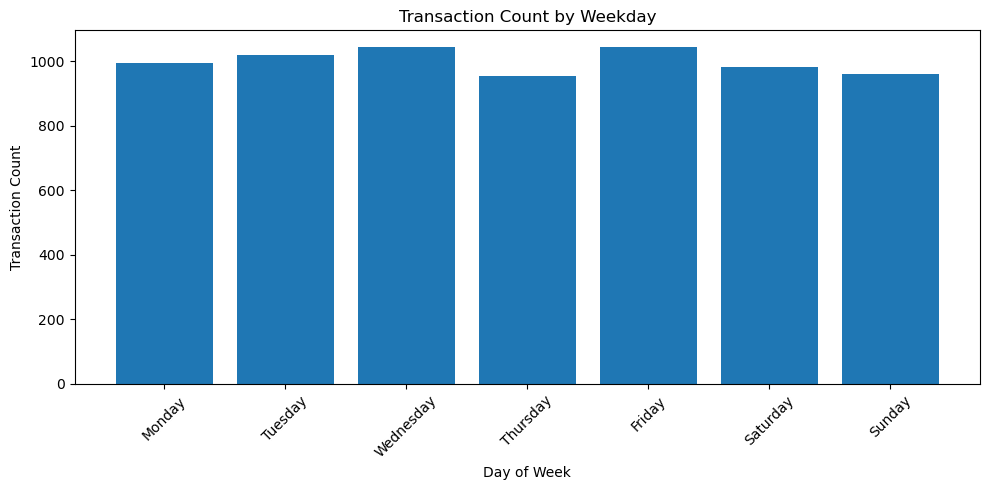

In [102]:
plt.figure(figsize=(10,5))

plt.bar(
    weekday_transactions["weekday_name"],
    weekday_transactions["Transaction_Count"]
)

plt.title("Transaction Count by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Transaction Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../reports/figures/weekday_transaction_count.png", dpi=300)

plt.show()

## Insights



• Which day has the most transactions?

The day with the highest transaction count represents the busiest day of the week, indicating when customers perform the largest number of financial transactions.

• Which day has the highest spending?

The day with the highest total spending reflects the period of maximum customer expenditure and may be associated with salary credits, shopping, or bill payments.

• Are weekends more expensive?

If Saturday and Sunday show higher total or average spending than weekdays, customers tend to spend more on leisure, dining, shopping, and entertainment during weekends. Otherwise, spending is primarily concentrated on weekdays due to routine expenses and bill payments.

## Weekend vs Weekday

In [103]:
df["weekday_name"] = df["transaction_date"].dt.day_name()

df["Day_Type"] = df["weekday_name"].apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

df[["transaction_date", "weekday_name", "Day_Type"]].head()

,transaction_date,weekday_name,Day_Type
0,2018-01-01,Monday,Weekday
1,2018-01-01,Monday,Weekday
2,2018-01-01,Monday,Weekday
3,2018-01-01,Monday,Weekday
4,2018-01-02,Tuesday,Weekday


In [104]:
daytype_transactions = (
    df.groupby("Day_Type")
      .size()
      .reset_index(name="Transaction_Count")
)

daytype_transactions


,Day_Type,Transaction_Count
0,Weekday,5055
1,Weekend,1945


## Visualization

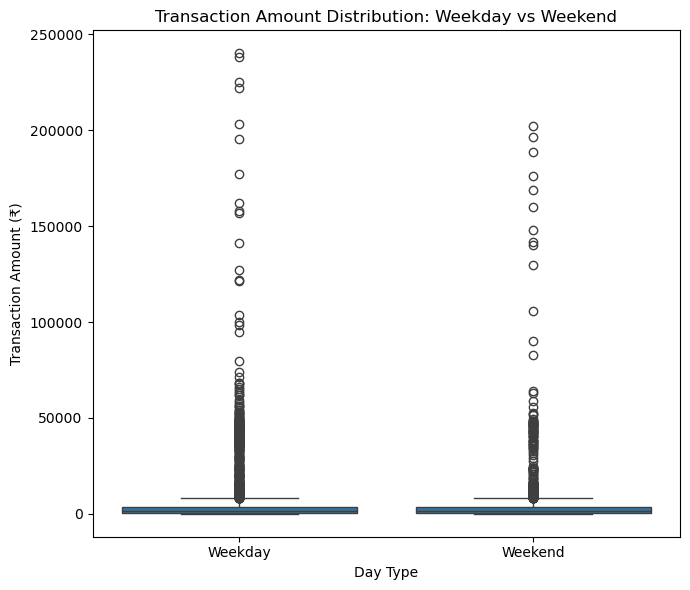

In [105]:
plt.figure(figsize=(7,6))

sns.boxplot(
    data=df,
    x="Day_Type",
    y="amount"
)

plt.title("Transaction Amount Distribution: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Transaction Amount (₹)")

plt.tight_layout()

plt.savefig(
    "../reports/figures/weekday_weekend_boxplot.png",
    dpi=300
)

plt.show()


##comparing categories

In [107]:
pd.crosstab(
    df["category"],
    df["weekend"]
)

weekend,0,1
category,,
Bills,1481,578
Entertainment,129,38
Food,1001,327
Fuel,307,116
Groceries,631,281
Insurance,111,41
Investment,27,9
Miscellaneous,248,110
Other,306,129


## Insights

• Does shopping increase on weekends?

If weekend shopping spending exceeds weekday spending, customers prefer making retail purchases during weekends when they have more leisure time.

• Does food spending increase on weekends?

Higher weekend food spending suggests increased dining out, food delivery, and social activities compared to weekdays.

## Transaction Time Analysis

In [108]:
#Extract Hour from Transaction Time
df["transaction_time"] = pd.to_datetime(
    df["transaction_time"],
    format="%H:%M:%S"
)

df["Hour"] = df["transaction_time"].dt.hour

df[["transaction_time", "Hour"]].head()

,transaction_time,Hour
0,1900-01-01 09:22:10,9
1,1900-01-01 12:33:23,12
2,1900-01-01 20:17:30,20
3,1900-01-01 21:33:19,21
4,1900-01-01 08:43:33,8


In [109]:
#Transaction Count by Hour
hourly_transactions = (
    df.groupby("Hour")
      .size()
      .reset_index(name="Transaction_Count")
)

hourly_transactions

,Hour,Transaction_Count
0,0,137
1,1,97
2,2,77
3,3,97
4,4,74
5,5,77
6,6,260
7,7,276
8,8,516
9,9,579


In [110]:
hourly_summary = (
    df.groupby("Hour")["amount"]
      .agg(
          Transaction_Count="count",
          Total_Spending="sum",
          Average_Transaction="mean"
      )
      .round(2)
)

hourly_summary

,Transaction_Count,Total_Spending,Average_Transaction
Hour,,,
0,137,1256191.09,9169.28
1,97,1448492.95,14932.92
2,77,314221.56,4080.80
3,97,647947.09,6679.87
4,74,381891.79,5160.70
5,77,485318.13,6302.83
6,260,1257796.02,4837.68
7,276,1441449.05,5222.64
8,516,2108813.39,4086.85


In [119]:
#TIme of day Analysis
def get_time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["Time_Period"] = df["Hour"].apply(get_time_period)

time_period_summary = (
    df.groupby("Time_Period")
      .agg(
          Transaction_Count=("amount", "count"),
          Total_Spending=("amount", "sum"),
          Average_Transaction=("amount", "mean")
      )
      .round(2)
)

time_period_summary

,Transaction_Count,Total_Spending,Average_Transaction
Time_Period,,,
Afternoon,1903,7991374.29,4199.36
Evening,1259,6665163.03,5294.01
Morning,2712,12491062.44,4605.85
Night,1126,7780131.51,6909.53


## Visualization

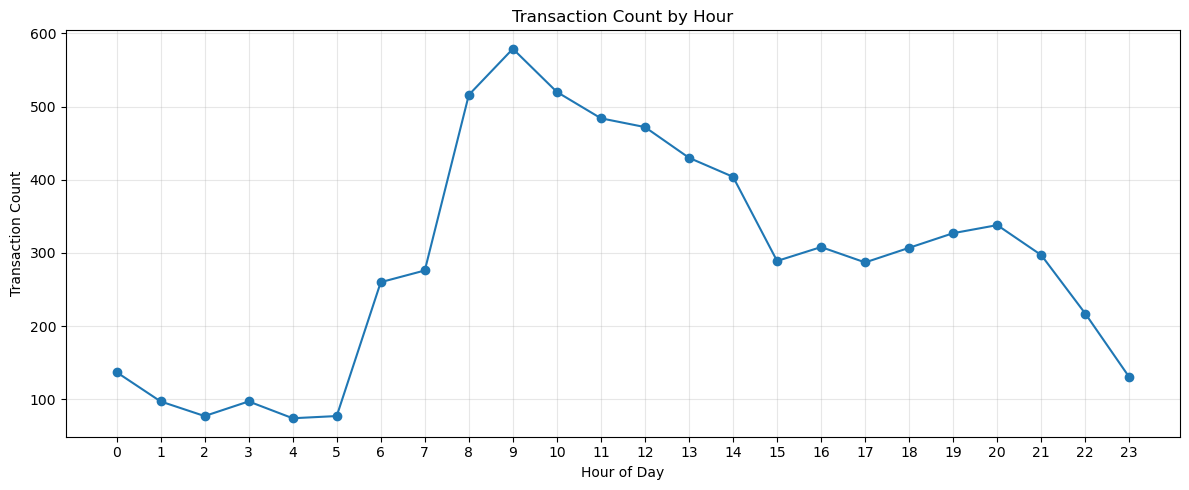

In [ ]:
#Transaction by Hour Plot
plt.figure(figsize=(12,5))
plt.plot(hourly_summary.index, hourly_summary["Transaction_Count"], marker="o")
plt.xlabel("Hour")
plt.ylabel("Transaction Count")
plt.title("Transaction Count by Hour")
plt.show()

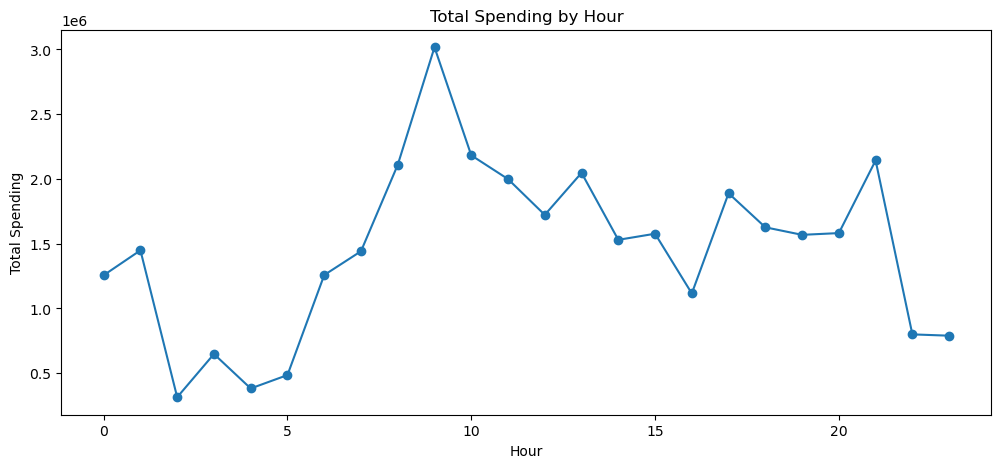

In [118]:
#Spending by Hour Plot
plt.figure(figsize=(12,5))
plt.plot(hourly_summary.index, hourly_summary["Total_Spending"], marker="o")
plt.xlabel("Hour")
plt.ylabel("Total Spending")
plt.title("Total Spending by Hour")
plt.show()

## Visualization



• Peak transaction hour?

The hour with the highest transaction count represents the busiest period of the day, indicating when customers perform the maximum number of financial transactions.

• Peak spending hour?

The hour with the highest total spending reflects the time when customers make the largest overall purchases, highlighting peak expenditure periods.

• Morning vs afternoon vs evening?

Comparing Morning, Afternoon, and Evening reveals customer preferences for conducting transactions throughout the day. Higher activity in a specific period indicates the most preferred time for spending and financial transactions.

## Month-End Spending 



In [124]:
#Transaction Count 
month_end_transactions = (
    df.groupby("month_end")
      .size()
      .reset_index(name="Transaction_Count")
)

month_end_transactions


,month_end,Transaction_Count
0,0,6691
1,1,309


In [123]:
month_end_spending = (
    df.groupby("month_end")["amount"]
      .sum()
      .reset_index(name="Total_Spending")
)

month_end_spending

,month_end,Total_Spending
0,0,33703193.24
1,1,1224538.03


In [121]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time', 'merchant',
       'description', 'amount', 'currency', 'payment_method',
       'transaction_type', 'category', 'city', 'state', 'country', 'day',
       'week', 'month', 'weekend', 'month_end', 'salary_week',
       'festival_season', 'Year', 'Month_Name', 'WeekDay_Name', 'Month',
       'weekday_name', 'Day_Type', 'Hour', 'Time_Period'],
      dtype='object')

In [125]:
month_end_summary = (
    df.groupby("month_end")
      .agg(
          Transaction_Count=("amount", "count"),
          Total_Spending=("amount", "sum"),
          Average_Transaction=("amount", "mean")
      )
      .round(2)
)

month_end_summary

,Transaction_Count,Total_Spending,Average_Transaction
month_end,,,
0,6691,33703193.24,5037.09
1,309,1224538.03,3962.91


In [128]:
month_end_category = (
    df.groupby(["category", "month_end"])["amount"]
      .sum()
      .reset_index()
)

month_end_pivot = month_end_category.pivot(
    index="category",
    columns="month_end",
    values="amount"
).fillna(0)

# Rename columns for clarity
month_end_pivot.columns = ["False", "True"]

month_end_pivot

,False,True
category,,
Bills,8450025.42,812511.04
Entertainment,95511.78,2563.59
Food,1043735.52,26070.07
Fuel,1214876.33,40923.73
Groceries,1146906.82,39636.33
Insurance,2084936.62,86339.16
Investment,819101.14,0.00
Miscellaneous,594620.91,41692.37
Other,429966.26,10806.44


## Insights

• Do customers spend more at month-end?

Higher spending on month_end = True suggests increased expenditure related to salary utilization, bill payments, or planned purchases near the end of the month.

• Which categories increase at month-end?

Categories with noticeably higher spending on month_end = True reflect expenses that are commonly scheduled toward the end of the month, such as bills, shopping, or groceries

## Salary Week Analysis

In [135]:
salary_category = pd.crosstab(
    df["salary_week"],
    df["salary_week"]
)

salary_category

salary_week,False,True
salary_week,,
False,5368,0
True,0,1632


In [132]:
salary_transaction = pd.crosstab(
    df["transaction_type"],
    df["salary_week"]
)

salary_transaction

salary_week,False,True
transaction_type,,
Credit,119,71
Debit,5249,1561


In [133]:
salary_category = pd.crosstab(
    df["category"],
    df["salary_week"]
)

salary_category

salary_week,False,True
category,,
Bills,1670,389
Entertainment,123,44
Food,1022,306
Fuel,324,99
Groceries,708,204
Insurance,116,36
Investment,0,36
Miscellaneous,277,81
Other,329,106


In [134]:
salary_category = pd.crosstab(
    df["amount"],
    df["salary_week"]
)

salary_category

salary_week,False,True
amount,,
30.74,1,0
32.02,0,1
33.31,0,1
33.51,0,1
34.47,0,1
...,...,...
203265.19,0,1
222120.88,0,1
225266.29,0,1


In [131]:
salary_week_summary = (
    df.groupby("salary_week")
      .agg(
          Transaction_Count=("amount", "count"),
          Total_Spending=("amount", "sum"),
          Average_Transaction=("amount", "mean")
      )
      .round(2)
)

salary_week_summary

,Transaction_Count,Total_Spending,Average_Transaction
salary_week,,,
False,5368,21945549.91,4088.22
True,1632,12982181.36,7954.77


In [136]:
salary_category_amount = (
    df.groupby(["category", "salary_week"])["amount"]
      .sum()
      .unstack(fill_value=0)
)

salary_category_amount.columns = ["Non_Salary_Week", "Salary_Week"]

salary_category_amount

,Non_Salary_Week,Salary_Week
category,,
Bills,7774919.28,1487617.18
Entertainment,73567.71,24507.66
Food,840917.25,228888.34
Fuel,961897.22,293902.84
Groceries,925199.62,261343.53
Insurance,1644972.38,526303.40
Investment,0.00,819101.14
Miscellaneous,502149.25,134164.03
Other,325747.43,115025.27


### important for financial behavior analysis

## Insights

• Are credits concentrated around salary periods?

If credit transactions are noticeably higher during salary week than during non-salary weeks, it suggests that salary credits are concentrated around the salary period.

• Does spending increase shortly after salary?

If debit transactions and total spending are higher during salary week, customers tend to increase their spending shortly after receiving their salary.

## Festival Season Analysis

In [137]:
festival_summary = (
    df.groupby("festival_season")
      .agg(
          Transaction_Count=("amount", "count"),
          Total_Spending=("amount", "sum"),
          Average_Transaction=("amount", "mean")
      )
      .round(2)
)

festival_summary

,Transaction_Count,Total_Spending,Average_Transaction
festival_season,,,
0,5928,29715300.16,5012.70
1,1072,5212431.11,4862.34


In [138]:
festival_transaction = pd.crosstab(
    df["transaction_type"],
    df["festival_season"]
)

festival_transaction

festival_season,0,1
transaction_type,,
Credit,168,22
Debit,5760,1050


In [139]:
festival_transaction = pd.crosstab(
    df["category"],
    df["festival_season"]
)

festival_transaction

festival_season,0,1
category,,
Bills,1786,273
Entertainment,140,27
Food,1116,212
Fuel,355,68
Groceries,763,149
Insurance,133,19
Investment,32,4
Miscellaneous,295,63
Other,360,75


In [140]:
festival_transaction = pd.crosstab(
    df["amount"],
    df["festival_season"]
)

festival_transaction

festival_season,0,1
amount,,
30.74,1,0
32.02,1,0
33.31,1,0
33.51,0,1
34.47,1,0
...,...,...
203265.19,1,0
222120.88,1,0
225266.29,1,0


In [141]:
festival_category = (
    df.groupby(["category", "festival_season"])["amount"]
      .sum()
      .unstack(fill_value=0)
)

festival_category.columns = ["Non_Festival", "Festival"]

festival_category

,Non_Festival,Festival
category,,
Bills,8027871.36,1234665.10
Entertainment,85318.49,12756.88
Food,884746.29,185059.30
Fuel,1064911.78,190888.28
Groceries,998499.56,188043.59
Insurance,1899310.01,271965.77
Investment,723959.86,95141.28
Miscellaneous,529107.98,107205.30
Other,374535.82,66236.88


In [142]:
festival_category["Higher_Spending"] = festival_category.idxmax(axis=1)

festival_category

,Non_Festival,Festival,Higher_Spending
category,,,
Bills,8027871.36,1234665.10,Non_Festival
Entertainment,85318.49,12756.88,Non_Festival
Food,884746.29,185059.30,Non_Festival
Fuel,1064911.78,190888.28,Non_Festival
Groceries,998499.56,188043.59,Non_Festival
Insurance,1899310.01,271965.77,Non_Festival
Investment,723959.86,95141.28,Non_Festival
Miscellaneous,529107.98,107205.30,Non_Festival
Other,374535.82,66236.88,Non_Festival


## Insights

• Does spending increase?

If total spending is higher during the festival season than the non-festival season, it indicates that customers increase their overall expenditure during festivals.

• Which categories increase?

Categories with higher spending during the festival season reflect purchases influenced by festive celebrations and seasonal demand.

• Does Shopping increase?

If Shopping spending is higher during the festival season, customers are likely making more purchases for gifts, clothing, electronics, and other festival-related items.

• Does Travel increase?

If Travel spending increases during the festival season, it suggests customers are spending more on vacations, family visits, and holiday trips.

• Does Food increase?

If Food spending is higher during the festival season, customers are likely spending more on dining, groceries, celebrations, and festive meals.

## Outlier Analysis

In [143]:
Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound :", lower)
print("Upper Bound :", upper)

Lower Bound : -4208.50125
Upper Bound : 8318.24875


In [144]:
outliers = df[
    (df["amount"] < lower) |
    (df["amount"] > upper)
]

outliers.head()

,transaction_id,transaction_date,transaction_time,merchant,description,amount,currency,payment_method,transaction_type,category,...,festival_season,Year,Month_Name,WeekDay_Name,Month,weekday_name,Day_Type,Hour,Time_Period,Month_Period
4,TXN000005,2018-01-02,1900-01-01 08:43:33,House Rent Payment,NEFT Rent Payment,44800.94,INR,NEFT,Debit,Rent,...,0,2018,1,Tuesday,1,Tuesday,Weekday,8,Morning,Start
17,TXN000018,2018-01-05,1900-01-01 09:39:46,House Rent Payment,NEFT Rent Payment,42338.57,INR,NEFT,Debit,Rent,...,0,2018,1,Friday,1,Friday,Weekday,9,Morning,Start
26,TXN000027,2018-01-10,1900-01-01 07:50:11,Credit Card Bill Payment,Auto Debit Credit Card Bill Payment,14999.79,INR,Auto Debit,Debit,Bills,...,0,2018,1,Wednesday,1,Wednesday,Weekday,7,Morning,Start
32,TXN000033,2018-01-12,1900-01-01 09:36:28,Employer Salary Credit,NEFT Salary Credit,46314.09,INR,NEFT,Credit,Salary,...,0,2018,1,Friday,1,Friday,Weekday,9,Morning,Middle
38,TXN000039,2018-01-15,1900-01-01 10:59:29,Credit Card Bill Payment,Auto Debit Credit Card Bill Payment,14256.14,INR,Auto Debit,Debit,Bills,...,0,2018,1,Monday,1,Monday,Weekday,10,Morning,Middle


In [145]:
print("Total Outliers :", len(outliers))

print(
    "Percentage :",
    round(len(outliers) / len(df) * 100, 2),
    "%"
)

Total Outliers : 863
Percentage : 12.33 %


In [147]:
# Top 20 Largest transactions 
top_transactions = (
    df.sort_values("amount", ascending=False)
      .head(20)
)

top_transactions

,transaction_id,transaction_date,transaction_time,merchant,description,amount,currency,payment_method,transaction_type,category,...,festival_season,Year,Month_Name,WeekDay_Name,Month,weekday_name,Day_Type,Hour,Time_Period,Month_Period
5966,TXN005869,2018-11-05,1900-01-01 13:54:23,Employer Salary Credit,NEFT Salary Credit,240125.84,INR,IMPS,Credit,Salary,...,1,2018,11,Monday,11,Monday,Weekday,13,Afternoon,Start
5584,TXN006406,2018-07-04,1900-01-01 19:44:29,Employer Salary Credit,NEFT Salary Credit,238163.14,INR,IMPS,Credit,Salary,...,0,2018,7,Wednesday,7,Wednesday,Weekday,19,Evening,Start
6246,TXN006660,2019-02-05,1900-01-01 11:04:09,Employer Salary Credit,NEFT Salary Credit,225266.29,INR,NEFT,Credit,Salary,...,0,2019,2,Tuesday,2,Tuesday,Weekday,11,Morning,Start
6442,TXN005465,2019-04-03,1900-01-01 13:55:52,Employer Salary Credit,NEFT Salary Credit,222120.88,INR,NEFT,Credit,Salary,...,0,2019,4,Wednesday,4,Wednesday,Weekday,13,Afternoon,Start
6614,TXN005372,2019-06-04,1900-01-01 21:14:15,Employer Salary Credit,NEFT Salary Credit,203265.19,INR,IMPS,Credit,Salary,...,0,2019,6,Tuesday,6,Tuesday,Weekday,21,Night,Start
6536,TXN006332,2019-05-04,1900-01-01 21:10:09,Employer Salary Credit,NEFT Salary Credit,202071.67,INR,IMPS,Credit,Salary,...,0,2019,5,Saturday,5,Saturday,Weekend,21,Night,Start
6902,TXN006634,2019-09-01,1900-01-01 14:11:16,Employer Salary Credit,NEFT Salary Credit,196659.20,INR,IMPS,Credit,Salary,...,0,2019,9,Sunday,9,Sunday,Weekend,14,Afternoon,Start
6906,TXN006082,2019-09-02,1900-01-01 17:35:54,Employer Salary Credit,NEFT Salary Credit,195608.36,INR,NEFT,Credit,Salary,...,0,2019,9,Monday,9,Monday,Weekday,17,Evening,Start
6242,TXN006212,2019-02-03,1900-01-01 21:37:03,Employer Salary Credit,NEFT Salary Credit,188574.21,INR,IMPS,Credit,Salary,...,0,2019,2,Sunday,2,Sunday,Weekend,21,Night,Start
5181,TXN006073,2018-03-02,1900-01-01 19:28:37,Employer Salary Credit,NEFT Salary Credit,177208.79,INR,NEFT,Credit,Salary,...,0,2018,3,Friday,3,Friday,Weekday,19,Evening,Start


In [148]:
# outlier analysis by category
outlier_category = (
    outliers.groupby("category")
            .size()
            .sort_values(ascending=False)
            .reset_index(name="Outlier_Count")
)

outlier_category

,category,Outlier_Count
0,Bills,349
1,Salary,163
2,Rent,117
3,Insurance,109
4,Shopping,92
5,Investment,27
6,Miscellaneous,6


In [149]:
#outlier analysis by merchant
outlier_merchant = (
    outliers.groupby("merchant")
            .size()
            .sort_values(ascending=False)
            .head(15)
            .reset_index(name="Outlier_Count")
)

outlier_merchant

,merchant,Outlier_Count
0,Employer Salary Credit,163
1,House Rent Payment,117
2,Credit Card Bill Payment,48
3,ICICI Lombard,32
4,Bajaj Allianz,31
5,Jio,28
6,Adani Electricity,27
7,Jio Fiber,26
8,Income Tax Payment,25
9,EMI Home Loan,25


## Insights

• Are there extreme transactions?

Transactions above the upper IQR bound are considered potential outliers and represent unusually large spending compared to typical customer behavior.

• Which categories contain the most outliers?

Categories with the highest outlier counts indicate where large-value purchases occur most frequently and may require additional monitoring.

• Which merchants generate the largest transactions?

Merchants associated with the most outliers are responsible for a significant share of high-value transactions and may represent premium purchases or recurring large payments.

• Should outliers be removed?

For financial transaction data, outliers often represent genuine customer behavior rather than errors. They should generally be retained for fraud detection, spending analysis, and predictive modeling unless they are confirmed to be data quality issues.

## Correlation Analysis

In [150]:
numerical_df = df.select_dtypes(include=["number"])

numerical_df.head()

,amount,day,week,month,weekend,month_end,festival_season,Year,Month_Name,Month,Hour
0,4361.84,1,1,1,0,0,0,2018,1,1,9
1,1226.03,1,1,1,0,0,0,2018,1,1,12
2,523.73,1,1,1,0,0,0,2018,1,1,20
3,1290.29,1,1,1,0,0,0,2018,1,1,21
4,44800.94,2,1,1,0,0,0,2018,1,1,8


In [151]:
correlation_matrix = numerical_df.corr(numeric_only=True)

correlation_matrix

,amount,day,week,month,weekend,month_end,festival_season,Year,Month_Name,Month,Hour
amount,1.000000,-0.083675,-0.016263,-0.009843,0.000738,-0.016027,-0.003933,0.013261,-0.009843,-0.009843,-0.023646
day,-0.083675,1.000000,0.076433,-0.002634,-0.007342,0.338930,-0.008125,-0.005462,-0.002634,-0.002634,-0.009769
week,-0.016263,0.076433,1.000000,0.980988,-0.000036,-0.013572,0.653874,-0.206670,0.980988,0.980988,0.015708
month,-0.009843,-0.002634,0.980988,1.000000,0.011345,-0.005358,0.675730,-0.217805,1.000000,1.000000,0.015962
weekend,0.000738,-0.007342,-0.000036,0.011345,1.000000,0.004878,0.002778,0.015195,0.011345,0.011345,0.016935
month_end,-0.016027,0.338930,-0.013572,-0.005358,0.004878,1.000000,-0.004483,-0.008294,-0.005358,-0.005358,0.008548
festival_season,-0.003933,-0.008125,0.653874,0.675730,0.002778,-0.004483,1.000000,-0.340398,0.675730,0.675730,0.017468
Year,0.013261,-0.005462,-0.206670,-0.217805,0.015195,-0.008294,-0.340398,1.000000,-0.217805,-0.217805,-0.026188
Month_Name,-0.009843,-0.002634,0.980988,1.000000,0.011345,-0.005358,0.675730,-0.217805,1.000000,1.000000,0.015962
Month,-0.009843,-0.002634,0.980988,1.000000,0.011345,-0.005358,0.675730,-0.217805,1.000000,1.000000,0.015962


## Visualization

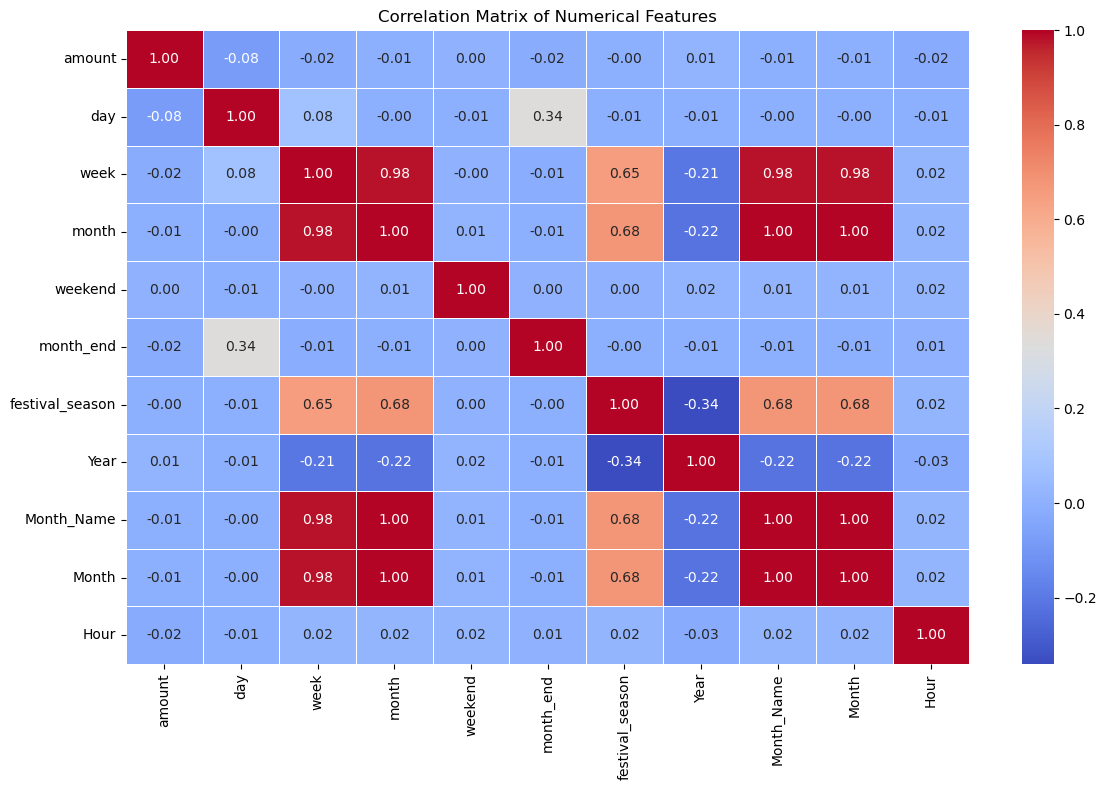

In [152]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()

plt.savefig("../reports/figures/correlation_heatmap.png", dpi=300)

plt.show()

## Feature Relationship Analysis

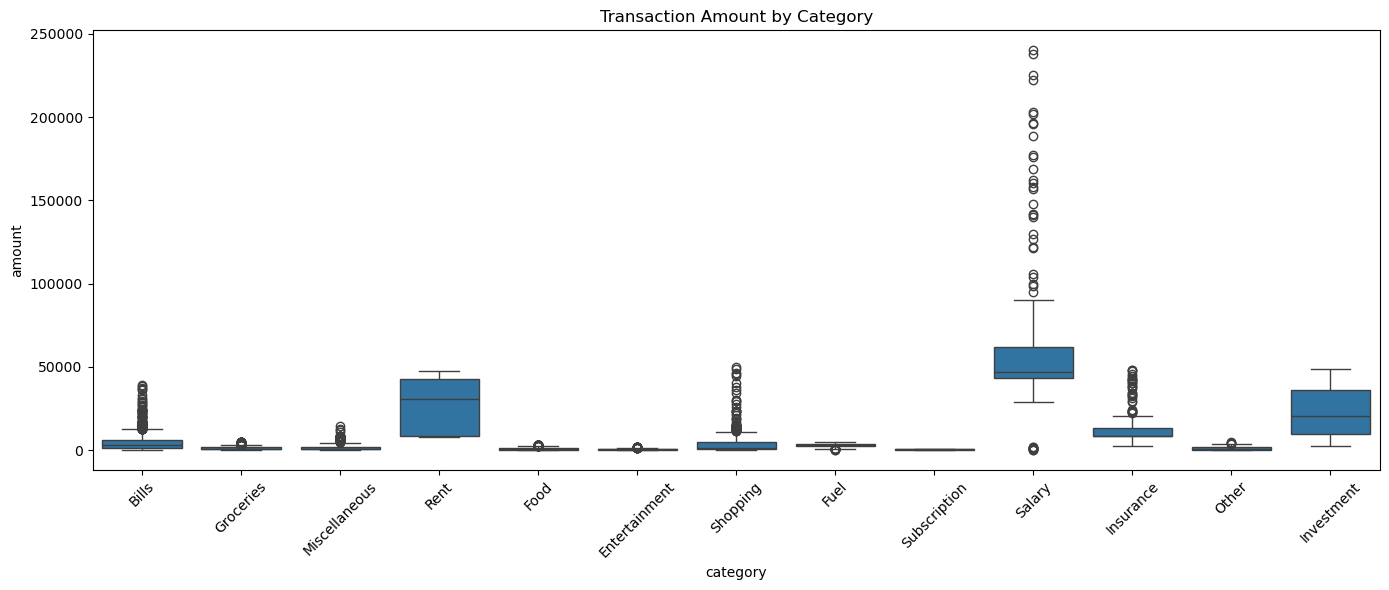

In [153]:
# amount vs category
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df,
    x="category",
    y="amount"
)

plt.xticks(rotation=45)
plt.title("Transaction Amount by Category")

plt.tight_layout()

plt.savefig("../reports/figures/category_amount_relationship.png", dpi=300)

plt.show()

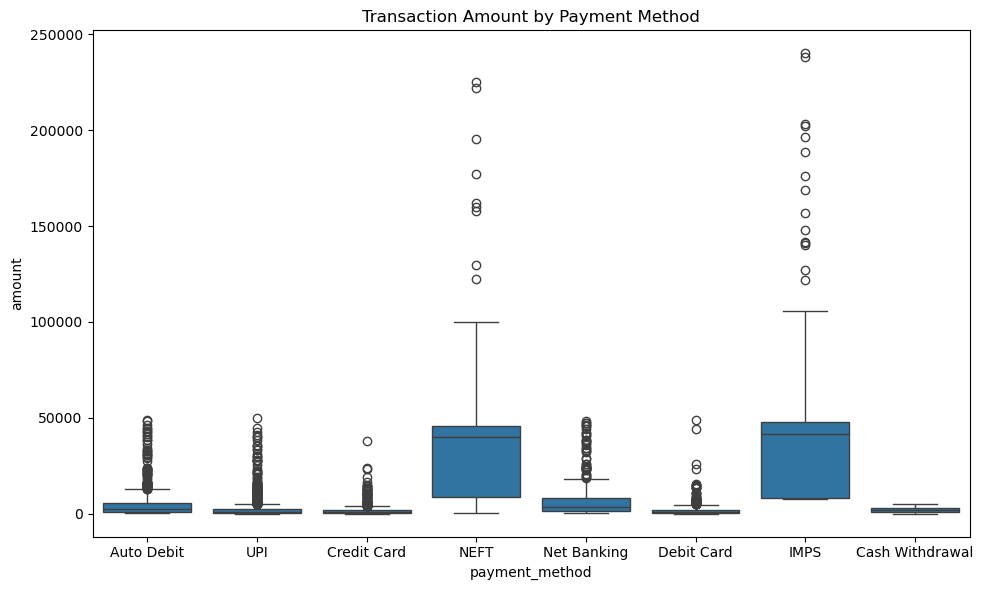

In [154]:
# amount vs payment_method
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="payment_method",
    y="amount"
)

plt.title("Transaction Amount by Payment Method")

plt.tight_layout()

plt.savefig("../reports/figures/payment_amount_relationship.png", dpi=300)

plt.show()

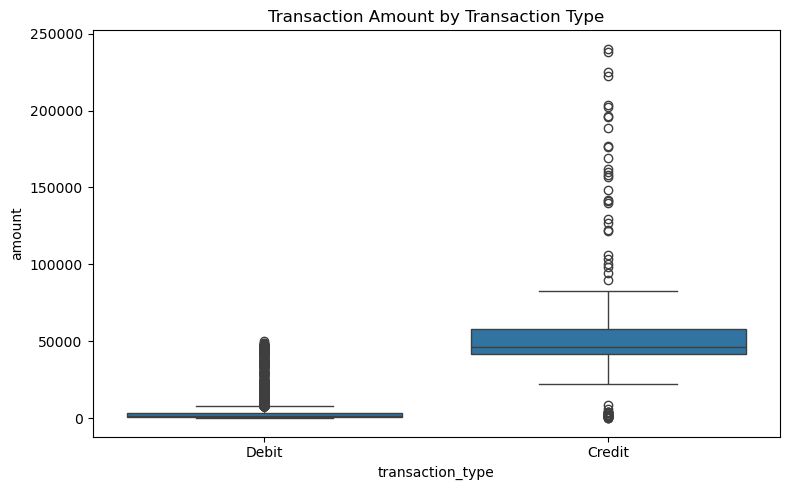

In [155]:
# amount vs transaction type
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="transaction_type",
    y="amount"
)

plt.title("Transaction Amount by Transaction Type")

plt.tight_layout()

plt.savefig("../reports/figures/transaction_type_amount_relationship.png", dpi=300)

plt.show()

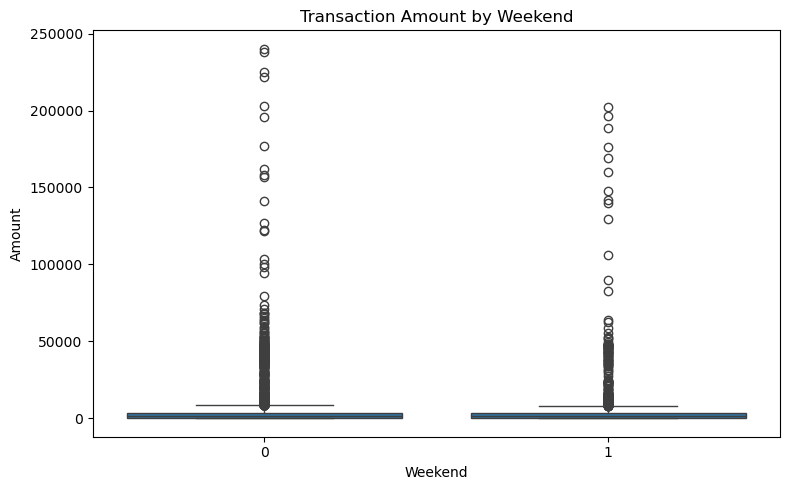

In [156]:
# amount vs weekend
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="weekend",
    y="amount"
)

plt.title("Transaction Amount by Weekend")
plt.xlabel("Weekend")
plt.ylabel("Amount")

plt.tight_layout()
plt.savefig("../reports/figures/weekend_amount_relationship.png", dpi=300)
plt.show()

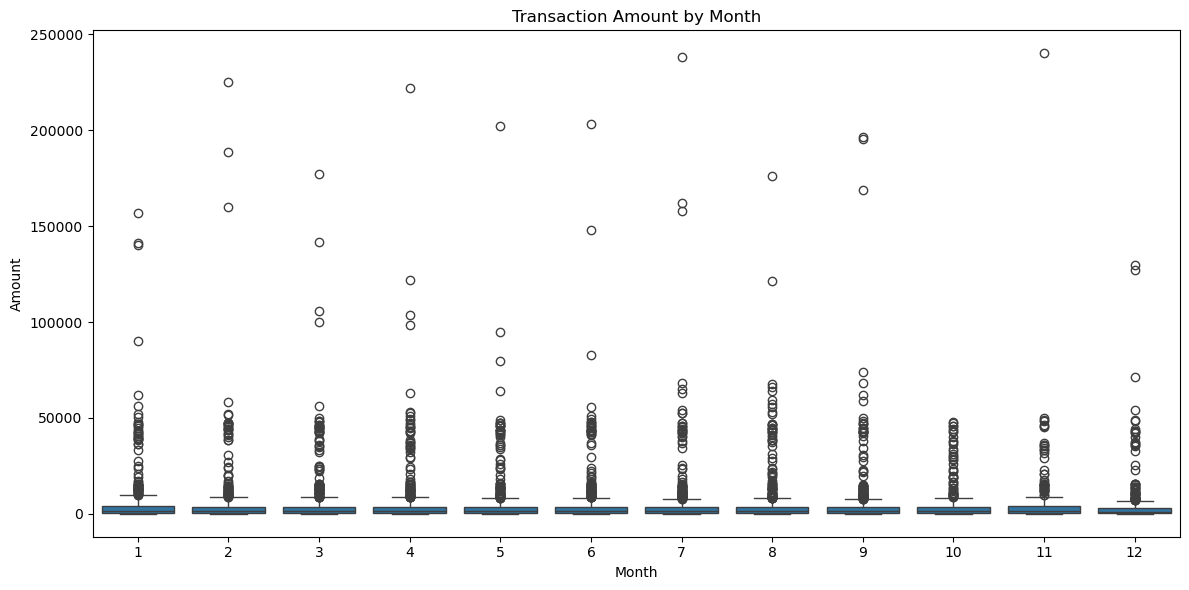

In [157]:
# amount vs month 
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="month", y="amount")
plt.title("Transaction Amount by Month")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.tight_layout()
plt.savefig("../reports/figures/month_amount_relationship.png", dpi=300)
plt.show()


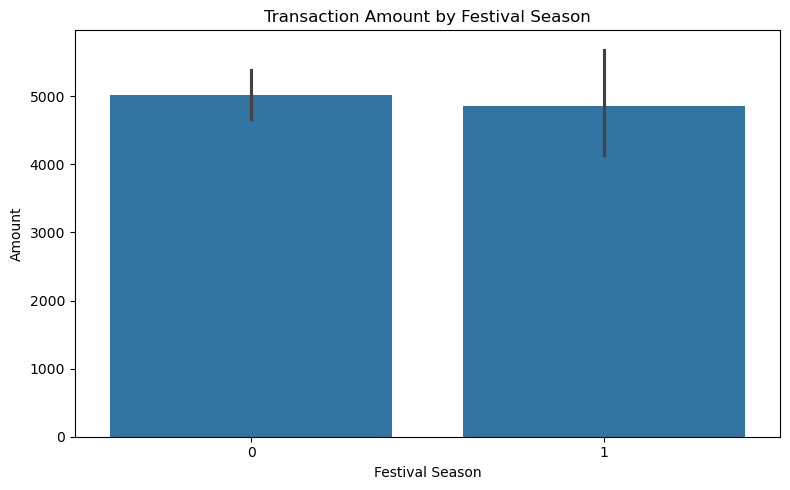

In [158]:
# amount vs festival_season
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="festival_season", y="amount")
plt.title("Transaction Amount by Festival Season")
plt.xlabel("Festival Season")
plt.ylabel("Amount")
plt.tight_layout()
plt.savefig("../reports/figures/festival_season_amount_relationship.png", dpi=300)
plt.show()


## ML Readiness -- Expense Classification

In [159]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 7000
Columns : 29


In [162]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [163]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [164]:
category_distribution = (
    df["category"]
      .value_counts()
      .reset_index()
)

category_distribution.columns = ["Category", "Count"]

category_distribution

,Category,Count
0,Bills,2059
1,Food,1328
2,Groceries,912
3,Shopping,550
4,Other,435
5,Fuel,423
6,Miscellaneous,358
7,Subscription,242
8,Salary,173
9,Entertainment,167


In [165]:
df.dtypes

transaction_id              object
transaction_date    datetime64[ns]
transaction_time    datetime64[ns]
merchant                    object
description                 object
amount                     float64
currency                    object
payment_method              object
transaction_type            object
category                    object
city                        object
state                       object
country                     object
day                          int64
week                         int64
month                        int64
weekend                      int64
month_end                    int64
salary_week                   bool
festival_season              int64
Year                         int32
Month_Name                   int32
WeekDay_Name                object
Month                        int32
weekday_name                object
Day_Type                    object
Hour                         int32
Time_Period                 object
Month_Period        

In [166]:
categorical_cols = df.select_dtypes(include="object").columns

cardinality = pd.DataFrame({
    "Feature": categorical_cols,
    "Unique_Values": [df[col].nunique() for col in categorical_cols]
})

cardinality

,Feature,Unique_Values
0,transaction_id,7000
1,merchant,99
2,description,1176
3,currency,1
4,payment_method,8
5,transaction_type,2
6,category,13
7,city,15
8,state,11
9,country,1


In [167]:
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time', 'merchant',
       'description', 'amount', 'currency', 'payment_method',
       'transaction_type', 'category', 'city', 'state', 'country', 'day',
       'week', 'month', 'weekend', 'month_end', 'salary_week',
       'festival_season', 'Year', 'Month_Name', 'WeekDay_Name', 'Month',
       'weekday_name', 'Day_Type', 'Hour', 'Time_Period', 'Month_Period'],
      dtype='object')

In [172]:
selected_features = [
    "merchant",
    "payment_method",
    "description",
    "transaction_type",
    "amount",
    "city",
    "state",
    "category",
    "Day_Type",
    "Month_Period",
    "salary_week",
    "festival_season",
    "month_end",
    "weekend",
]

df[selected_features].head()

,merchant,payment_method,description,transaction_type,amount,city,state,category,Day_Type,Month_Period,salary_week,festival_season,month_end,weekend
0,Credit Card Bill Payment,Auto Debit,Auto Debit Credit Card Bill Payment,Debit,4361.84,Bengaluru,Karnataka,Bills,Weekday,Start,True,0,0,0
1,Zepto,UPI,UPI/Paytm/Zepto,Debit,1226.03,Bengaluru,Karnataka,Groceries,Weekday,Start,True,0,0,0
2,Ace Hardware India,Credit Card,POS Purchase Ace Hardware India,Debit,523.73,Bengaluru,Karnataka,Miscellaneous,Weekday,Start,True,0,0,0
3,Zepto,UPI,UPI/DR/623175732898/Zepto,Debit,1290.29,Indore,Madhya Pradesh,Groceries,Weekday,Start,True,0,0,0
4,House Rent Payment,NEFT,NEFT Rent Payment,Debit,44800.94,Pune,Maharashtra,Rent,Weekday,Start,True,0,0,0


## Visualization

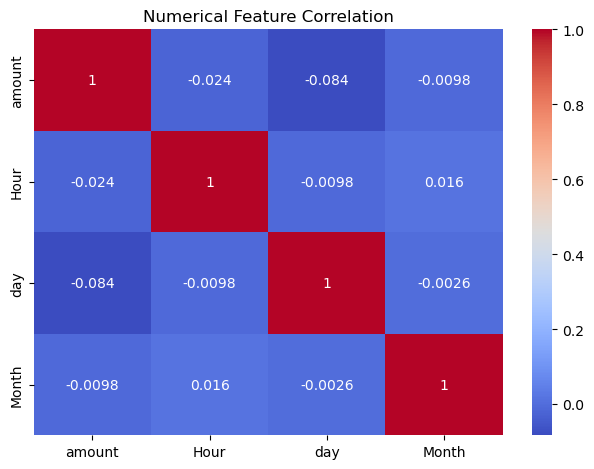

In [174]:
numerical_features = [
    "amount",
    "Hour",
    "day",
    "Month"
]

sns.heatmap(
    df[numerical_features].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation")

plt.tight_layout()

plt.savefig("../reports/figures/ml_feature_correlation.png", dpi=300)

plt.show()

## Final ML Checklist

In [175]:
ml_checklist = pd.DataFrame({
    "Checklist": [
        "Missing Values Removed",
        "Duplicates Removed",
        "Target Available",
        "Feature Engineered",
        "Date Features Created",
        "Time Features Created",
        "Category Labels Available",
        "Ready for Encoding",
        "Ready for Train/Test Split"
    ],
    "Status": [
        "Yes" if df.isnull().sum().sum() == 0 else "No",
        "Yes" if df.duplicated().sum() == 0 else "No",
        "Yes" if "category" in df.columns else "No",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes",
        "Yes"
    ]
})

ml_checklist

,Checklist,Status
0,Missing Values Removed,Yes
1,Duplicates Removed,Yes
2,Target Available,Yes
3,Feature Engineered,Yes
4,Date Features Created,Yes
5,Time Features Created,Yes
6,Category Labels Available,Yes
7,Ready for Encoding,Yes
8,Ready for Train/Test Split,Yes


## ML Readiness -- Forecasting

In [176]:
daily_spending = (
    df.groupby("transaction_date")["amount"]
      .sum()
      .reset_index()
)

daily_spending.head()

,transaction_date,amount
0,2018-01-01,77103.28
1,2018-01-02,99601.47
2,2018-01-03,28836.12
3,2018-01-04,52272.13
4,2018-01-05,117374.98


In [178]:
forecast_summary = daily_spending["amount"].describe()

forecast_summary

count       653.000000
mean      53488.103017
std       52993.226928
min        2693.690000
25%       19772.950000
50%       38349.200000
75%       68223.210000
max      368455.300000
Name: amount, dtype: float64

In [186]:
# check  missing dates
date_range = pd.date_range(
    start=df["transaction_date"].min(),
    end=df["transaction_date"].max()
)

missing_dates = date_range.difference(df["transaction_date"].unique())

print("Missing Dates :", len(missing_dates))

Missing Dates : 26


In [187]:
print("Missing Values:")
print(daily_spending.isnull().sum())

print("\nTotal Dates:", len(daily_spending))

Missing Values:
transaction_date    0
amount              0
dtype: int64

Total Dates: 679


## Budget Recommendation

In [188]:
monthly_budget = (
    df.groupby(["Month_Name", "category"])["amount"]
      .sum()
      .reset_index(name="Monthly_Spending")
)

monthly_budget.head()

,Month_Name,category,Monthly_Spending
0,1,Bills,906577.74
1,1,Entertainment,6611.87
2,1,Food,77696.67
3,1,Fuel,106101.91
4,1,Groceries,103887.59


In [189]:
avg_budget = (
    monthly_budget.groupby("category")["Monthly_Spending"]
                  .mean()
                  .sort_values(ascending=False)
                  .reset_index(name="Average_Monthly_Spending")
)

avg_budget

,category,Average_Monthly_Spending
0,Salary,929609.934167
1,Bills,771878.038333
2,Rent,365780.014167
3,Shopping,195800.541667
4,Insurance,180939.648333
5,Fuel,104650.005000
6,Groceries,98878.595833
7,Food,89150.465833
8,Investment,68258.428333
9,Miscellaneous,53026.106667


In [190]:
budget_recommendation = avg_budget.copy()

budget_recommendation["Recommended_Budget"] = (
    budget_recommendation["Average_Monthly_Spending"] * 1.20
).round(2)

budget_recommendation

,category,Average_Monthly_Spending,Recommended_Budget
0,Salary,929609.934167,1115531.92
1,Bills,771878.038333,926253.65
2,Rent,365780.014167,438936.02
3,Shopping,195800.541667,234960.65
4,Insurance,180939.648333,217127.58
5,Fuel,104650.005000,125580.01
6,Groceries,98878.595833,118654.31
7,Food,89150.465833,106980.56
8,Investment,68258.428333,81910.11
9,Miscellaneous,53026.106667,63631.33


In [191]:
budget_recommendation["Savings_Target"] = (
    budget_recommendation["Recommended_Budget"]
    - budget_recommendation["Average_Monthly_Spending"]
).round(2)

budget_recommendation

,category,Average_Monthly_Spending,Recommended_Budget,Savings_Target
0,Salary,929609.934167,1115531.92,185921.99
1,Bills,771878.038333,926253.65,154375.61
2,Rent,365780.014167,438936.02,73156.01
3,Shopping,195800.541667,234960.65,39160.11
4,Insurance,180939.648333,217127.58,36187.93
5,Fuel,104650.005000,125580.01,20930.00
6,Groceries,98878.595833,118654.31,19775.71
7,Food,89150.465833,106980.56,17830.09
8,Investment,68258.428333,81910.11,13651.68
9,Miscellaneous,53026.106667,63631.33,10605.22


In [192]:
top_budget_categories = (
    budget_recommendation.sort_values(
        "Average_Monthly_Spending",
        ascending=False
    )
)

top_budget_categories

,category,Average_Monthly_Spending,Recommended_Budget,Savings_Target
0,Salary,929609.934167,1115531.92,185921.99
1,Bills,771878.038333,926253.65,154375.61
2,Rent,365780.014167,438936.02,73156.01
3,Shopping,195800.541667,234960.65,39160.11
4,Insurance,180939.648333,217127.58,36187.93
5,Fuel,104650.005000,125580.01,20930.00
6,Groceries,98878.595833,118654.31,19775.71
7,Food,89150.465833,106980.56,17830.09
8,Investment,68258.428333,81910.11,13651.68
9,Miscellaneous,53026.106667,63631.33,10605.22


## Visualization

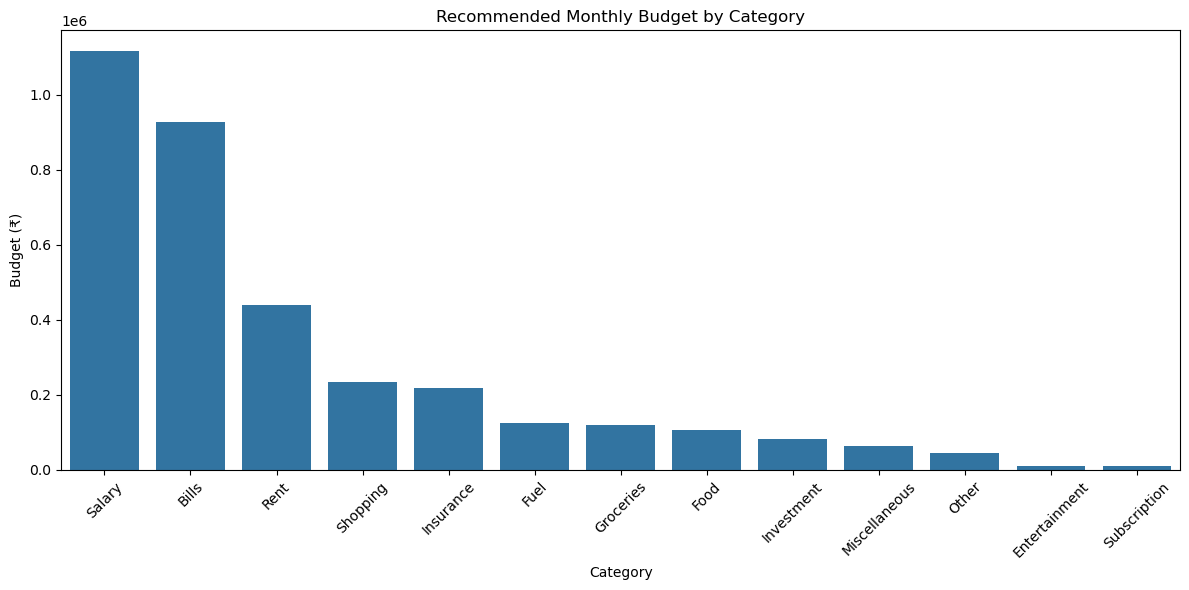

In [193]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=budget_recommendation,
    x="category",
    y="Recommended_Budget"
)

plt.xticks(rotation=45)

plt.title("Recommended Monthly Budget by Category")
plt.xlabel("Category")
plt.ylabel("Budget (₹)")

plt.tight_layout()

plt.savefig(
    "../reports/figures/recommended_budget.png",
    dpi=300
)

plt.show()